In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Summary statistics for numerical columns
numerical_summary = df.describe(include='number').T
print("Summary Statistics for Numerical Columns:\n")
print(numerical_summary)


Summary Statistics for Numerical Columns:

                   count          mean           std      min      25%  \
Age               1581.0     31.922201      8.425978     22.0     25.0   
No_of_Dependents  1581.0      2.457938      0.943483      0.0      2.0   
Salary            1581.0  60392.220114  14674.825044  30000.0  51900.0   
Partner_salary    1581.0  20225.559322  18905.183912      0.0      0.0   
Total_salary      1581.0  79625.996205  25545.857768  30000.0  60500.0   
Price             1581.0  35597.722960  13633.636545  18000.0  25000.0   

                      50%      75%       max  
Age                  29.0     38.0      54.0  
No_of_Dependents      2.0      3.0       4.0  
Salary            59500.0  71800.0   99300.0  
Partner_salary    24900.0  38000.0   80500.0  
Total_salary      78000.0  95900.0  171000.0  
Price             31000.0  47000.0   70000.0  


In [ ]:
# Value counts for categorical columns
categorical_columns = df.select_dtypes(include='object').columns
print("\nValue Counts for Categorical Columns:\n")
for col in categorical_columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())



Value Counts for Categorical Columns:


Column: Gender
Gender
Male      1252
Female     327
Femal        1
Femle        1
Name: count, dtype: int64

Column: Profession
Profession
Salaried    896
Business    685
Name: count, dtype: int64

Column: Marital_status
Marital_status
Married    1443
Single      138
Name: count, dtype: int64

Column: Education
Education
Post Graduate    985
Graduate         596
Name: count, dtype: int64

Column: Personal_loan
Personal_loan
Yes    792
No     789
Name: count, dtype: int64

Column: House_loan
House_loan
No     1054
Yes     527
Name: count, dtype: int64

Column: Partner_working
Partner_working
Yes    868
No     713
Name: count, dtype: int64

Column: Make
Make
Sedan        702
Hatchback    582
SUV          297
Name: count, dtype: int64


In [ ]:
# Check the structure of the data
print("Shape of the data:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nInfo summary:")
df.info()

Shape of the data: (1581, 15)

Column names: ['Age', 'Gender', 'Profession', 'Marital_status', 'Education', 'No_of_Dependents', 'Personal_loan', 'House_loan', 'Partner_working', 'Salary', 'Partner_salary', 'Total_salary', 'Price', 'Make', 'Partner_salary_missing']

Data types:
 Age                         int64
Gender                     object
Profession                 object
Marital_status             object
Education                  object
No_of_Dependents            int64
Personal_loan              object
House_loan                 object
Partner_working            object
Salary                      int64
Partner_salary            float64
Total_salary                int64
Price                       int64
Make                       object
Partner_salary_missing       bool
dtype: object

Info summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------           

In [ ]:
import pandas as pd

# Load the data
df = pd.read_csv('austo_automobile .csv')

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    mode = df[col].mode()[0]
    df[col] = df[col].fillna(mode)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    mean = df[col].mean()
    df[col] = df[col].fillna(mean)
print("\nMissing values after treatment:")
print(df.isnull().sum())

df_cleaned = df.dropna()

df_cleaned = df.dropna(axis=1)

df_filled = df.fillna(0)
df['Gender'] = df['Gender'].fillna('Unknown')
df['Partner_salary'] = df['Partner_salary'].fillna(df['Partner_salary'].mean())
df['Partner_salary'] = df['Partner_salary'].fillna(df['Partner_salary'].median())

df['Partner_salary_missing'] = df['Partner_salary'].isnull()





Missing values per column:
Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64

Missing values after treatment:
Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64


In [ ]:
import pandas as pd

# Load the data
df = pd.read_csv('austo_automobile .csv')

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64


In [ ]:
# Treat missing values
# For categorical columns: fill with mode
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    mode = df[col].mode()[0]
    df[col] = df[col].fillna(mode)
    # For numerical columns: fill with mean
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    mean = df[col].mean()
    df[col] = df[col].fillna(mean)

print("\nMissing values after treatment:")
print(df.isnull().sum())


Missing values after treatment:
Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64


In [ ]:
import pandas as pd
 # Load the data
df = pd.read_csv('austo_automobile .csv')
# For categorical columns: fill with mode
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    mode = df[col].mode()[0]
    df[col] = df[col].fillna(mode)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    mean = df[col].mean()
    df[col] = df[col].fillna(mean)

print("Updated Missing Value Counts After Treatment:")
print(df.isnull().sum())

Updated Missing Value Counts After Treatment:
Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64


In [ ]:
import pandas as pd

# Load the data
df = pd.read_csv('austo_automobile .csv')

# Treat missing values

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    mode = df[col].mode()[0]
    df[col] = df[col].fillna(mode)


numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    mean = df[col].mean()
    df[col] = df[col].fillna(mean)


print("Updated Missing Value Counts After Treatment:")
print(df.isnull().sum())

Updated Missing Value Counts After Treatment:
Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64


Numerical Summary Statistics:


,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
count,1581.000000,1581.000000,1581.000000,1475.000000,1581.000000,1581.000000
mean,31.922201,2.457938,60392.220114,20225.559322,79625.996205,35597.722960
std,8.425978,0.943483,14674.825044,19573.149277,25545.857768,13633.636545
min,22.000000,0.000000,30000.000000,0.000000,30000.000000,18000.000000
25%,25.000000,2.000000,51900.000000,0.000000,60500.000000,25000.000000
50%,29.000000,2.000000,59500.000000,25600.000000,78000.000000,31000.000000
75%,38.000000,3.000000,71800.000000,38300.000000,95900.000000,47000.000000
max,54.000000,4.000000,99300.000000,80500.000000,171000.000000,70000.000000


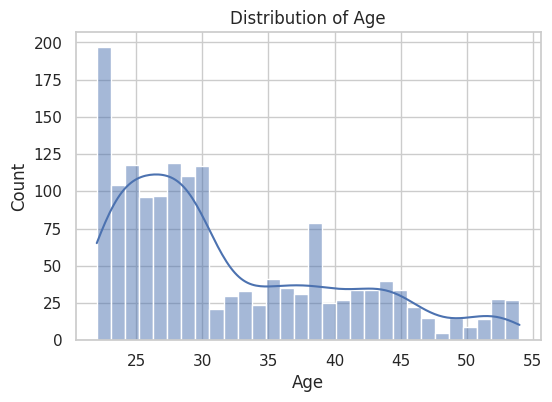

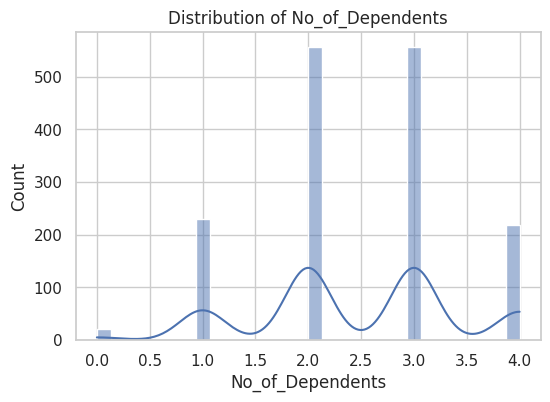

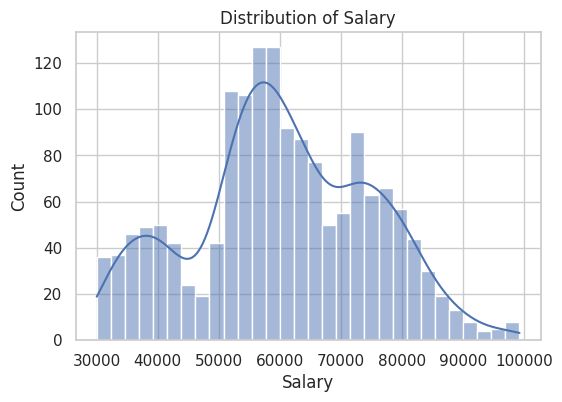

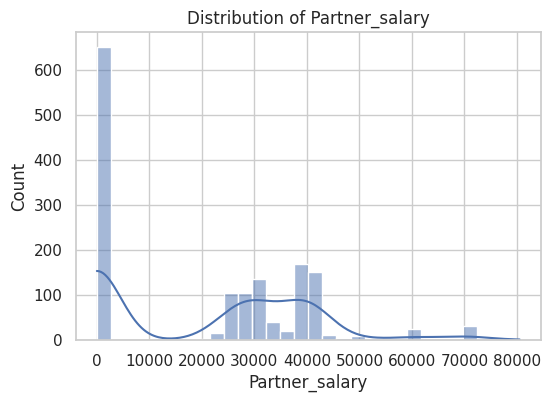

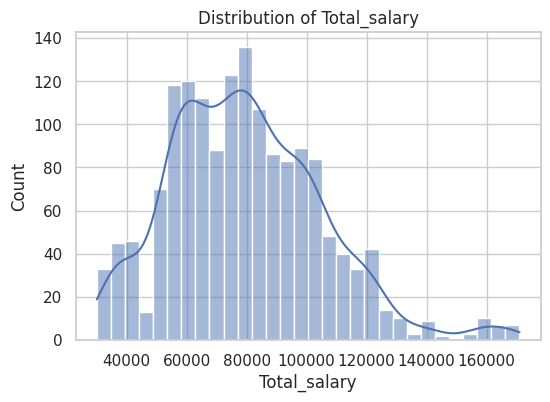

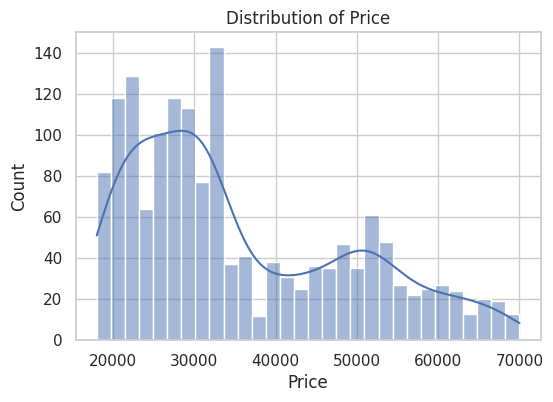


Value Counts for Gender:
Gender
Male      1199
Female     327
NaN         53
Femal        1
Femle        1
Name: count, dtype: int64


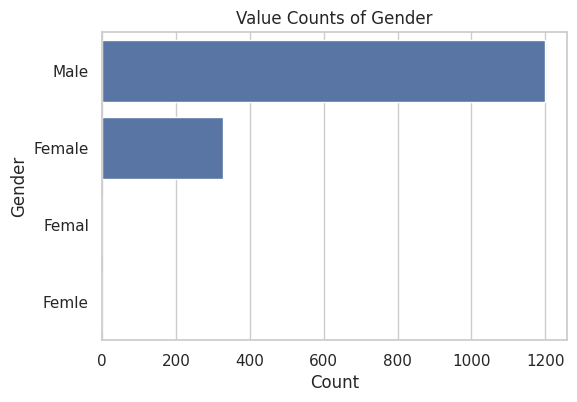


Value Counts for Profession:
Profession
Salaried    896
Business    685
Name: count, dtype: int64


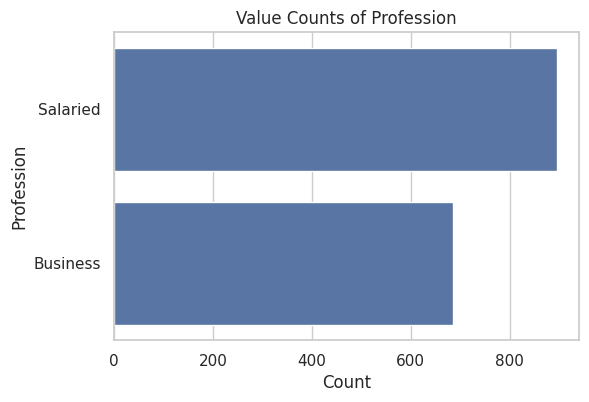


Value Counts for Marital_status:
Marital_status
Married    1443
Single      138
Name: count, dtype: int64


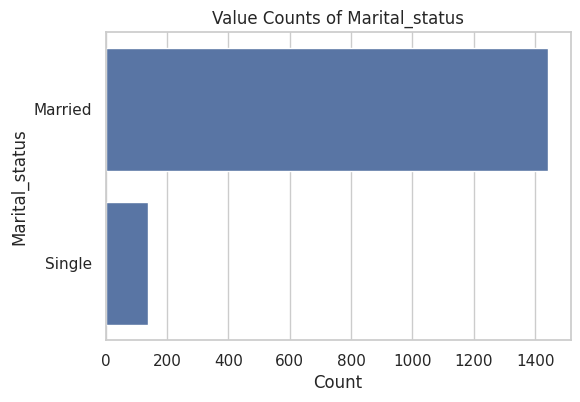


Value Counts for Education:
Education
Post Graduate    985
Graduate         596
Name: count, dtype: int64


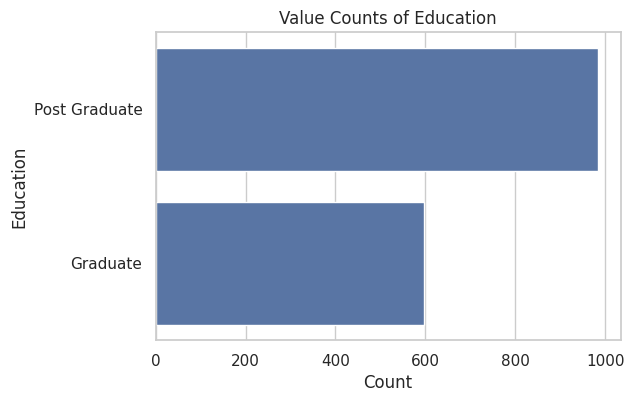


Value Counts for Personal_loan:
Personal_loan
Yes    792
No     789
Name: count, dtype: int64


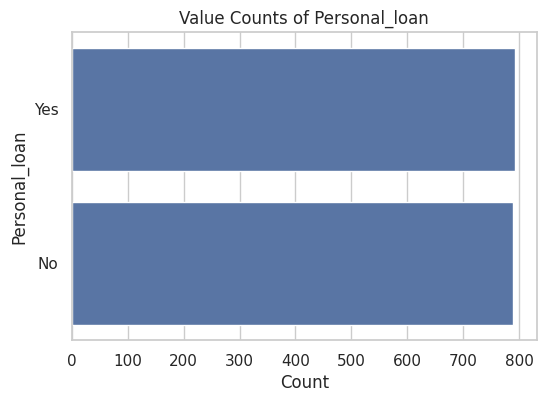


Value Counts for House_loan:
House_loan
No     1054
Yes     527
Name: count, dtype: int64


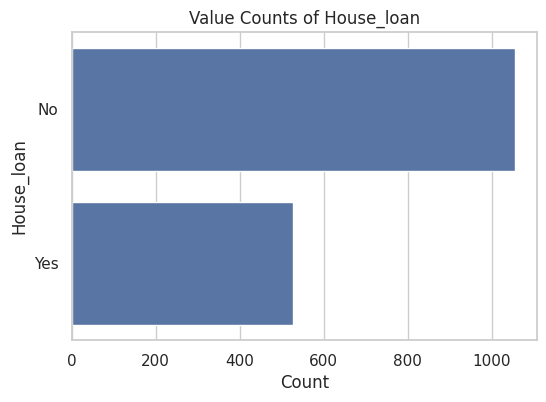


Value Counts for Partner_working:
Partner_working
Yes    868
No     713
Name: count, dtype: int64


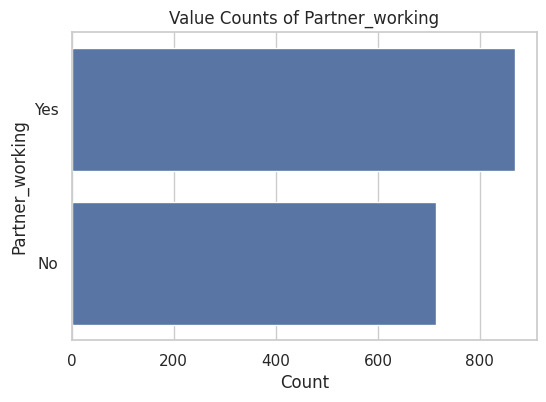


Value Counts for Make:
Make
Sedan        702
Hatchback    582
SUV          297
Name: count, dtype: int64


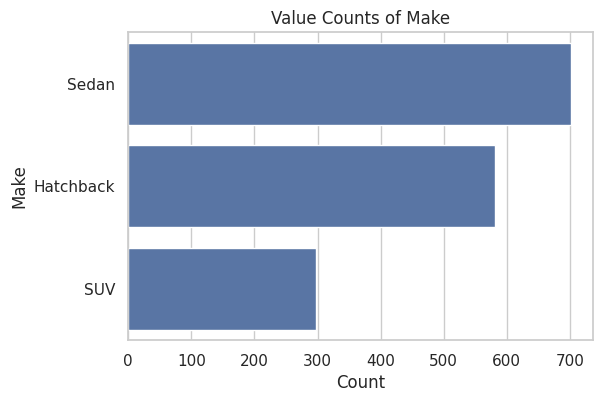

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('austo_automobile .csv')

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Summary Statistics:")
display(df[numerical_cols].describe())

for col in numerical_cols:
   plt.figure(figsize=(6, 4))
   sns.histplot(df[col], kde=True, bins=30)
   plt.title(f'Distribution of {col}')
   plt.xlabel(col)
   plt.ylabel('Count')
   plt.show()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
   print(f"\nValue Counts for {col}:")
   print(df[col].value_counts(dropna=False))
   plt.figure(figsize=(6, 4))
   sns.countplot(y=df[col], order=df[col].value_counts().index)
   plt.title(f'Value Counts of {col}')
   plt.xlabel('Count')
   plt.ylabel(col)
   plt.show()

In [ ]:

import pandas as pd
import numpy as np

df = pd.read_csv('austo_automobile .csv')

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

def cap_outliers(df, col):
   Q1 = df[col].quantile(0.25)
   Q3 = df[col].quantile(0.75)
   IQR = Q3 - Q1
   lower_bound = Q1 - 1.5 * IQR
   upper_bound = Q3 + 1.5 * IQR

   df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
   df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
   print(f"{col}: Outliers capped to [{lower_bound}, {upper_bound}]")

for col in numerical_cols:
   cap_outliers(df, col)

("\nSummary statistics after outlier treatment:")
display(df[numerical_cols].describe())

Age: Outliers capped to [5.5, 57.5]
No_of_Dependents: Outliers capped to [0.5, 4.5]
Salary: Outliers capped to [22050.0, 101650.0]
Partner_salary: Outliers capped to [-57450.0, 95750.0]
Total_salary: Outliers capped to [7400.0, 149000.0]
Price: Outliers capped to [-8000.0, 80000.0]


,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
count,1581.000000,1581.000000,1581.000000,1475.000000,1581.000000,1581.000000
mean,31.922201,2.464263,60392.220114,20225.559322,79398.545225,35597.722960
std,8.425978,0.928532,14674.825044,19573.149277,24849.147996,13633.636545
min,22.000000,0.500000,30000.000000,0.000000,30000.000000,18000.000000
25%,25.000000,2.000000,51900.000000,0.000000,60500.000000,25000.000000
50%,29.000000,2.000000,59500.000000,25600.000000,78000.000000,31000.000000
75%,38.000000,3.000000,71800.000000,38300.000000,95900.000000,47000.000000
max,54.000000,4.000000,99300.000000,80500.000000,149000.000000,70000.000000


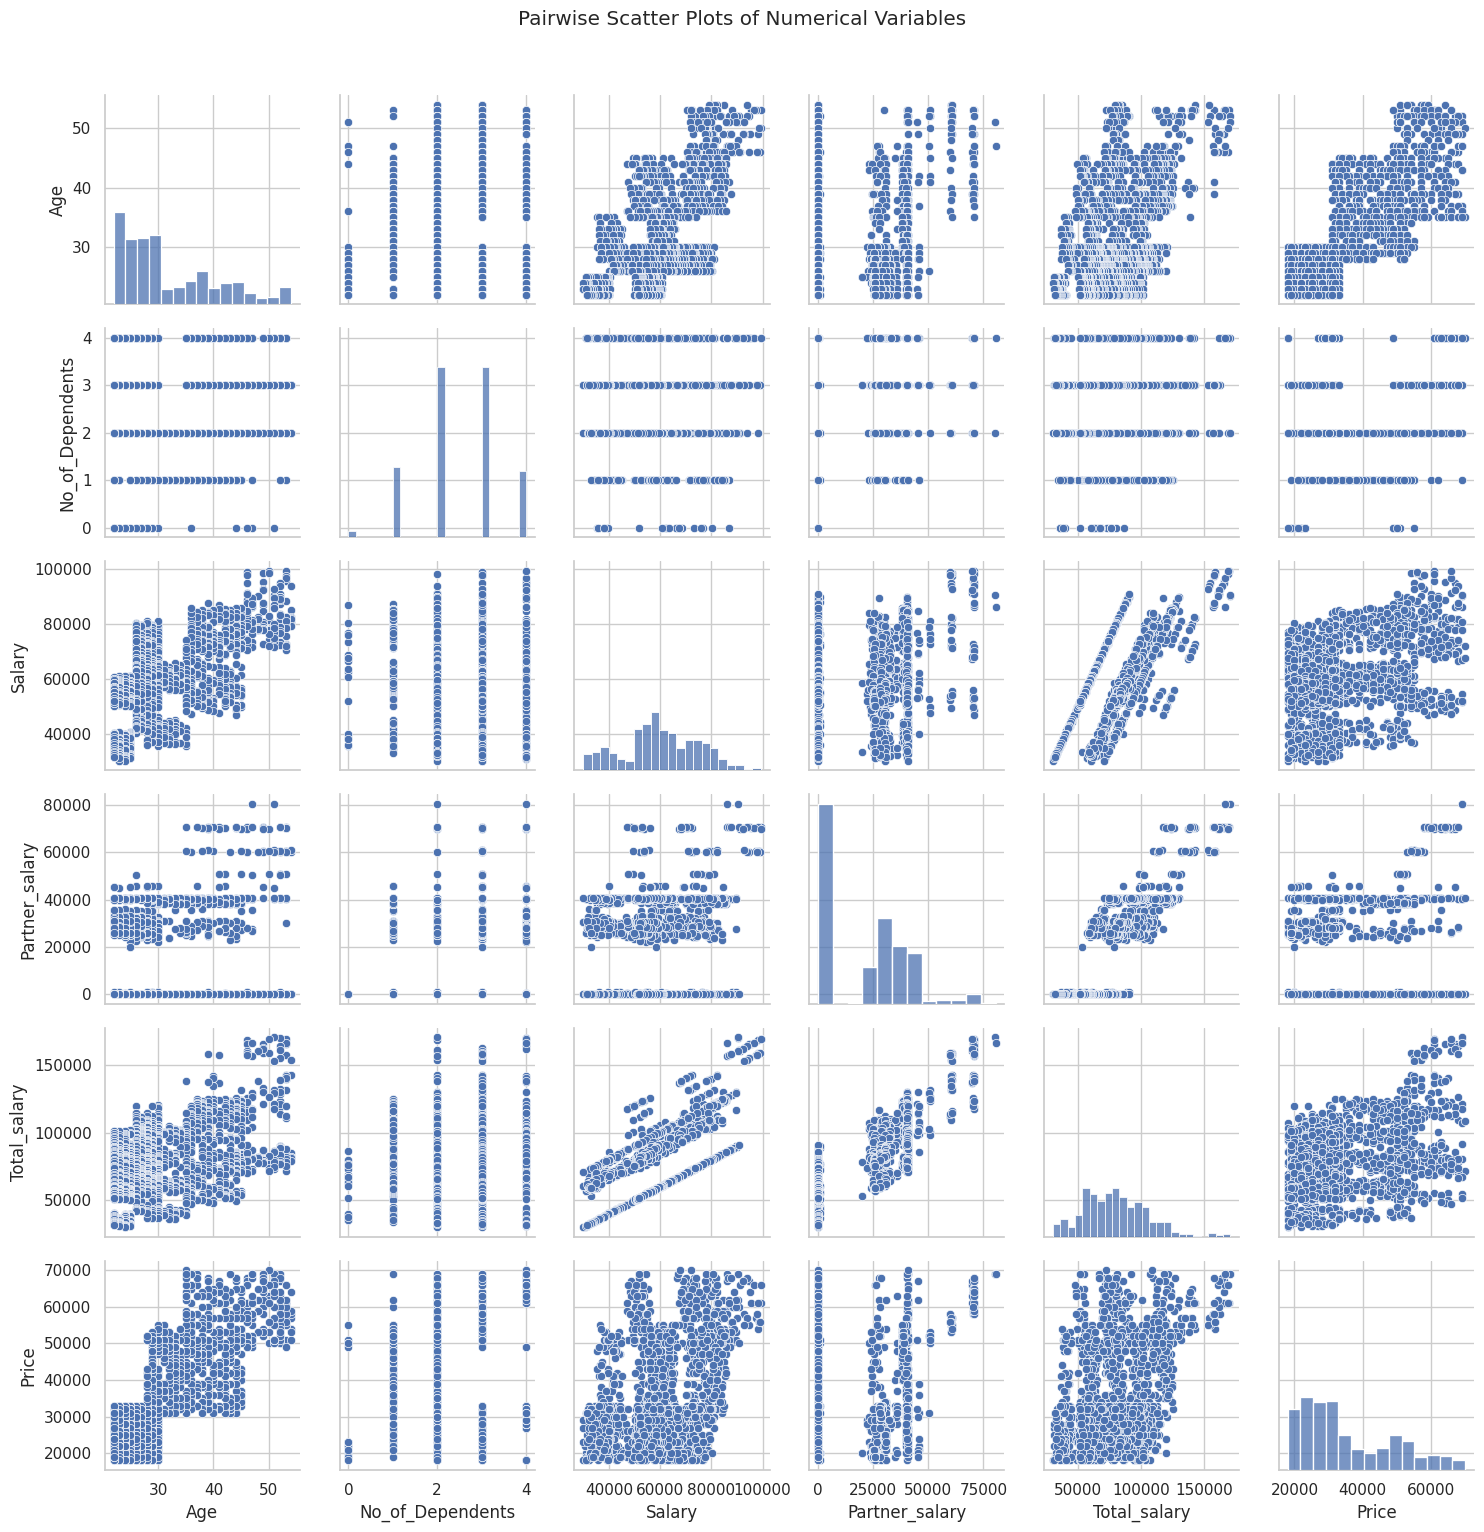

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Load the data
df = pd.read_csv('austo_automobile .csv')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.pairplot(df[numerical_cols])
plt.suptitle("Pairwise Scatter Plots of Numerical Variables", y=1.02)
plt.tight_layout()
plt.show()

Correlation Matrix:
                       Age  No_of_Dependents    Salary  Partner_salary  \
Age               1.000000         -0.189614  0.616899        0.126267   
No_of_Dependents -0.189614          1.000000 -0.031746        0.131253   
Salary            0.616899         -0.031746  1.000000        0.071049   
Partner_salary    0.126267          0.131253  0.071049        1.000000   
Total_salary      0.458869          0.092890  0.641560        0.813945   
Price             0.797831         -0.135839  0.409920        0.167725   

                  Total_salary     Price  
Age                   0.458869  0.797831  
No_of_Dependents      0.092890 -0.135839  
Salary                0.641560  0.409920  
Partner_salary        0.813945  0.167725  
Total_salary          1.000000  0.367823  
Price                 0.367823  1.000000  


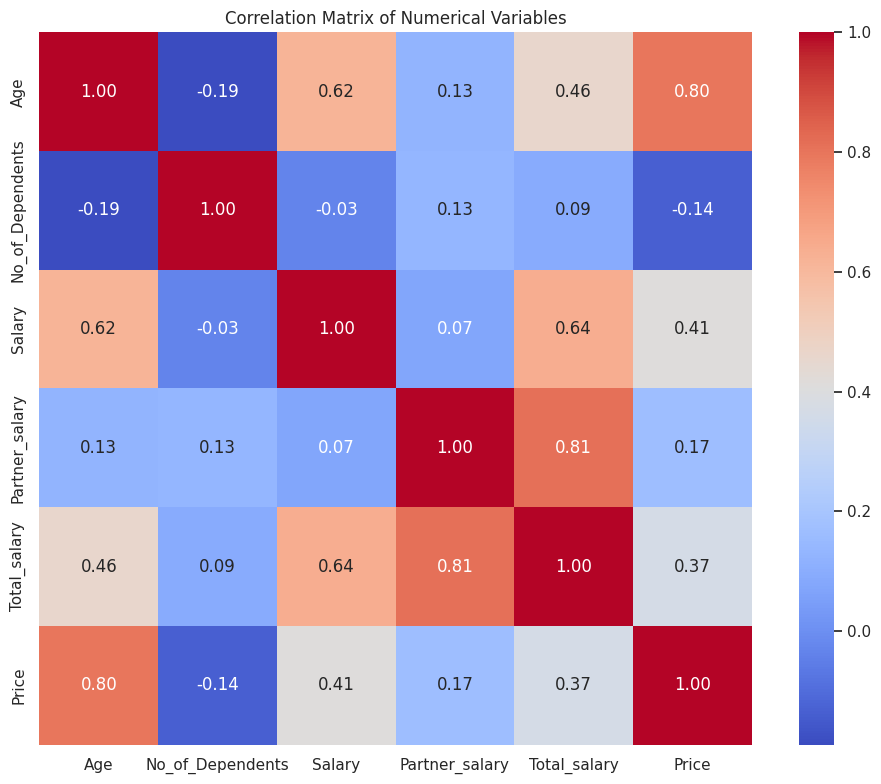

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('austo_automobile .csv')

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr_matrix = df[numerical_cols].corr()
print("Correlation Matrix:")
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

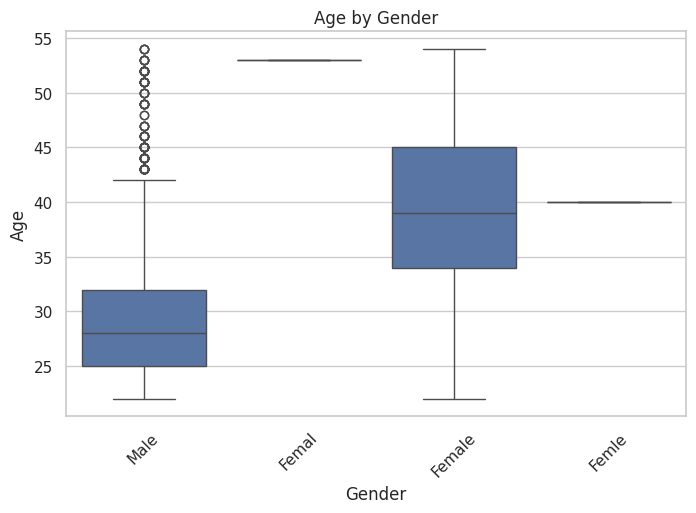


Group statistics for Age by Gender:
         count      mean       std   min   25%   50%   75%   max
Gender                                                          
Femal      1.0  53.00000       NaN  53.0  53.0  53.0  53.0  53.0
Female   327.0  39.48318  7.397077  22.0  34.0  39.0  45.0  54.0
Femle      1.0  40.00000       NaN  40.0  40.0  40.0  40.0  40.0
Male    1199.0  29.95246  7.500378  22.0  25.0  28.0  32.0  54.0


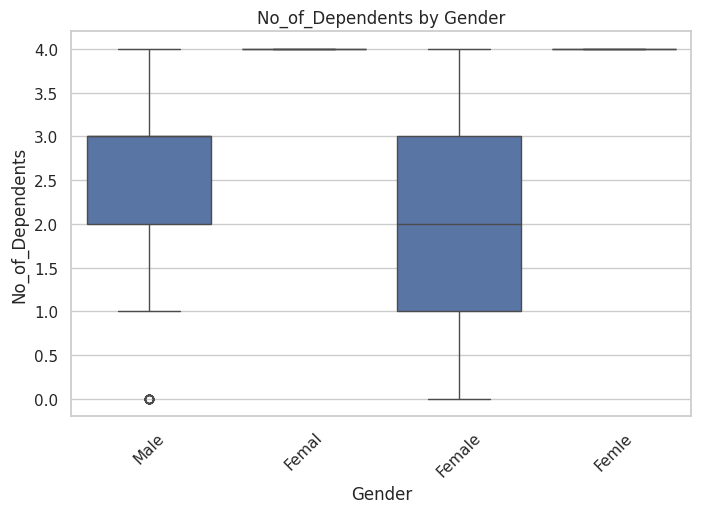


Group statistics for No_of_Dependents by Gender:
         count      mean       std  min  25%  50%  75%  max
Gender                                                     
Femal      1.0  4.000000       NaN  4.0  4.0  4.0  4.0  4.0
Female   327.0  2.027523  0.914693  0.0  1.0  2.0  3.0  4.0
Femle      1.0  4.000000       NaN  4.0  4.0  4.0  4.0  4.0
Male    1199.0  2.561301  0.917846  0.0  2.0  3.0  3.0  4.0


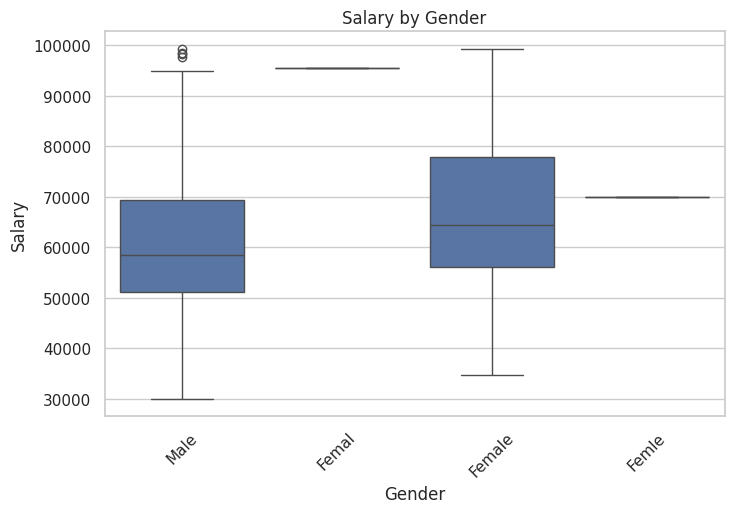


Group statistics for Salary by Gender:
         count          mean           std      min      25%      50%  \
Gender                                                                  
Femal      1.0  95500.000000           NaN  95500.0  95500.0  95500.0   
Female   327.0  66093.272171  14529.804908  34800.0  56100.0  64500.0   
Femle      1.0  70000.000000           NaN  70000.0  70000.0  70000.0   
Male    1199.0  58878.065054  14320.213282  30000.0  51200.0  58500.0   

            75%      max  
Gender                    
Femal   95500.0  95500.0  
Female  77950.0  99300.0  
Femle   70000.0  70000.0  
Male    69350.0  99300.0  


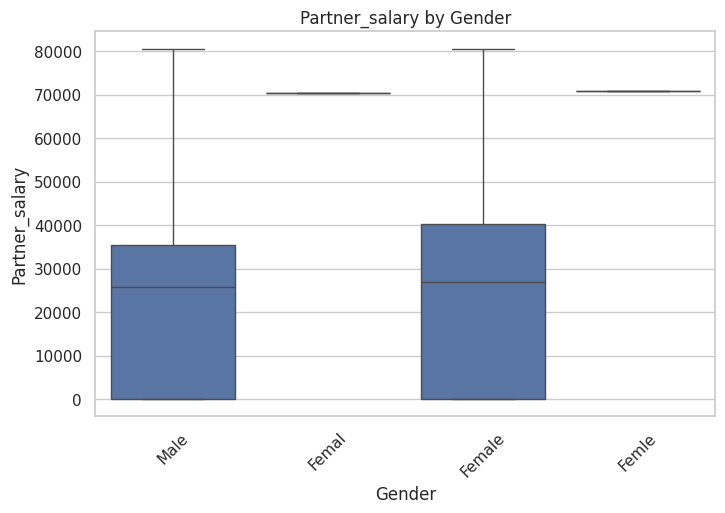


Group statistics for Partner_salary by Gender:
         count          mean           std      min      25%      50%  \
Gender                                                                  
Femal      1.0  70300.000000           NaN  70300.0  70300.0  70300.0   
Female   303.0  22984.488449  22818.554166      0.0      0.0  27000.0   
Femle      1.0  70800.000000           NaN  70800.0  70800.0  70800.0   
Male    1120.0  19767.589286  18559.727835      0.0      0.0  25700.0   

            75%      max  
Gender                    
Femal   70300.0  70300.0  
Female  40200.0  80400.0  
Femle   70800.0  70800.0  
Male    35425.0  80500.0  


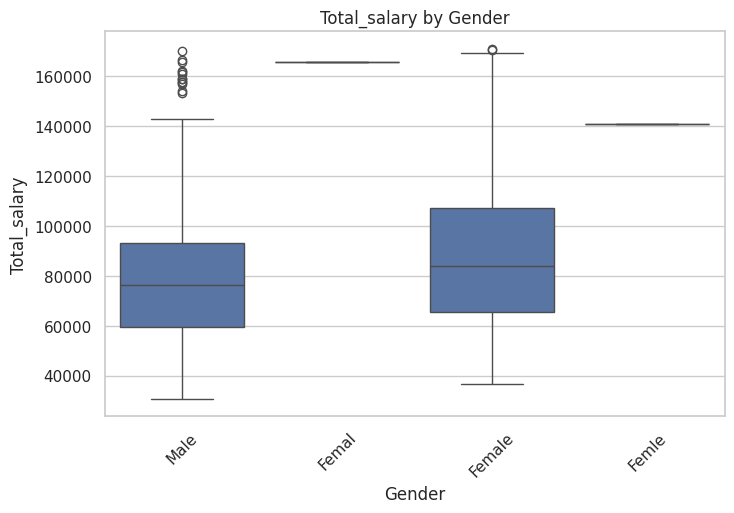


Group statistics for Total_salary by Gender:
         count           mean           std       min       25%       50%  \
Gender                                                                      
Femal      1.0  165800.000000           NaN  165800.0  165800.0  165800.0   
Female   327.0   88294.189602  28748.183136   36800.0   65600.0   83800.0   
Femle      1.0  140800.000000           NaN  140800.0  140800.0  140800.0   
Male    1199.0   77577.147623  24023.731899   30600.0   59500.0   76300.0   

             75%       max  
Gender                      
Femal   165800.0  165800.0  
Female  107200.0  171000.0  
Femle   140800.0  140800.0  
Male     93350.0  170000.0  


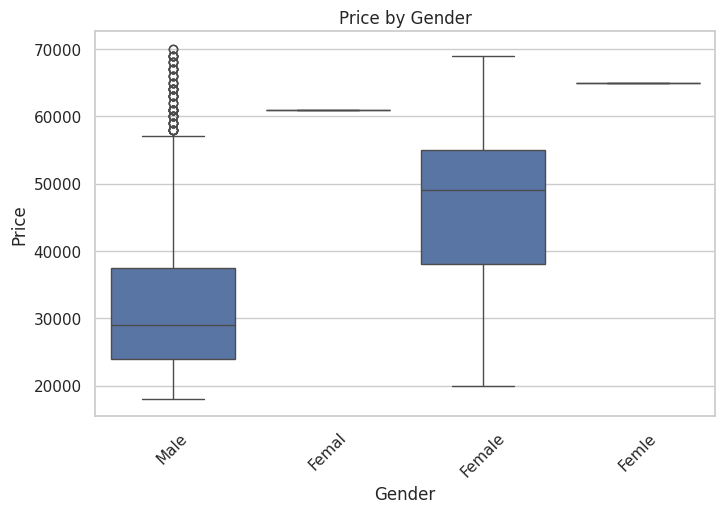


Group statistics for Price by Gender:
         count          mean           std      min      25%      50%  \
Gender                                                                  
Femal      1.0  61000.000000           NaN  61000.0  61000.0  61000.0   
Female   327.0  47611.620795  11213.991567  20000.0  38000.0  49000.0   
Femle      1.0  65000.000000           NaN  65000.0  65000.0  65000.0   
Male    1199.0  32817.347790  12299.239195  18000.0  24000.0  29000.0   

            75%      max  
Gender                    
Femal   61000.0  61000.0  
Female  55000.0  69000.0  
Femle   65000.0  65000.0  
Male    37500.0  70000.0  


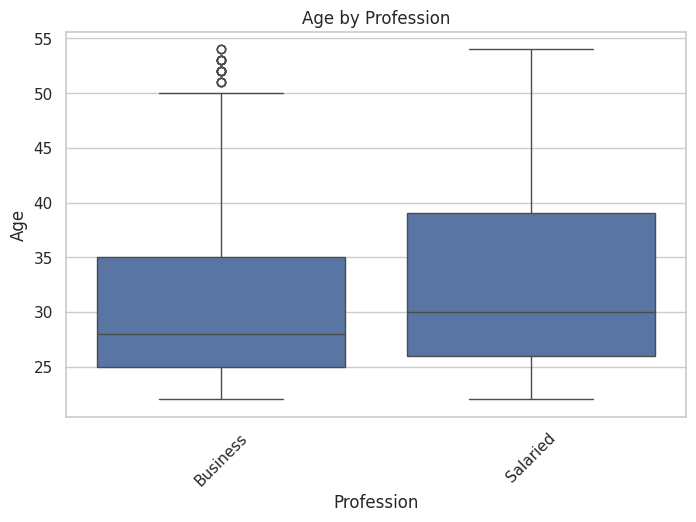


Group statistics for Age by Profession:
            count       mean       std   min   25%   50%   75%   max
Profession                                                          
Business    685.0  30.563504  7.808798  22.0  25.0  28.0  35.0  54.0
Salaried    896.0  32.960938  8.731605  22.0  26.0  30.0  39.0  54.0


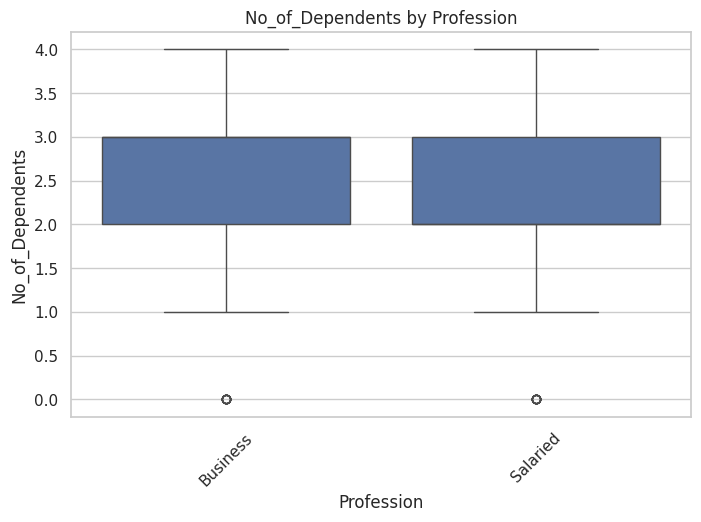


Group statistics for No_of_Dependents by Profession:
            count      mean       std  min  25%  50%  75%  max
Profession                                                    
Business    685.0  2.490511  0.931254  0.0  2.0  3.0  3.0  4.0
Salaried    896.0  2.433036  0.952493  0.0  2.0  2.0  3.0  4.0


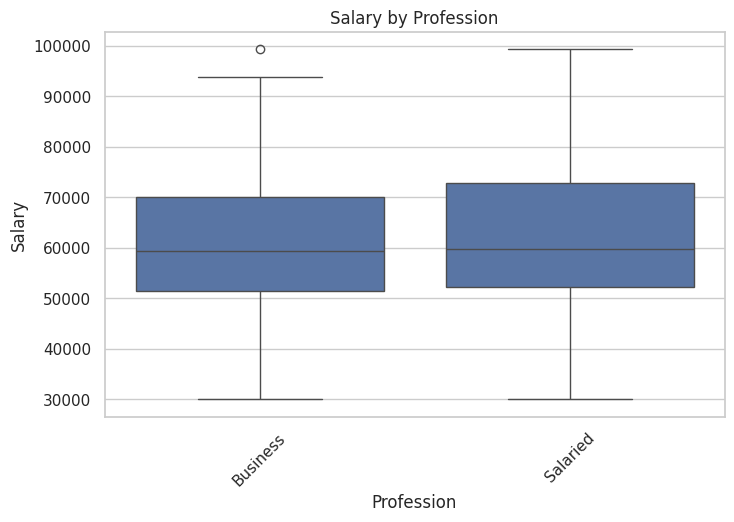


Group statistics for Salary by Profession:
            count          mean           std      min      25%      50%  \
Profession                                                                 
Business    685.0  59578.978102  14286.122641  30000.0  51400.0  59300.0   
Salaried    896.0  61013.950893  14943.266102  30000.0  52175.0  59800.0   

                75%      max  
Profession                    
Business    70100.0  99300.0  
Salaried    72800.0  99300.0  


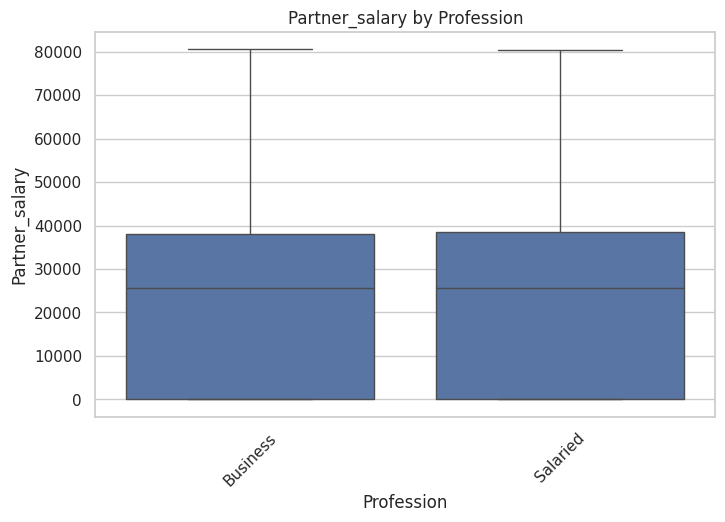


Group statistics for Partner_salary by Profession:
            count          mean          std  min  25%      50%      75%  \
Profession                                                                 
Business    644.0  19816.614907  18768.74707  0.0  0.0  25650.0  38100.0   
Salaried    831.0  20542.478941  20180.01309  0.0  0.0  25600.0  38500.0   

                max  
Profession           
Business    80500.0  
Salaried    80400.0  


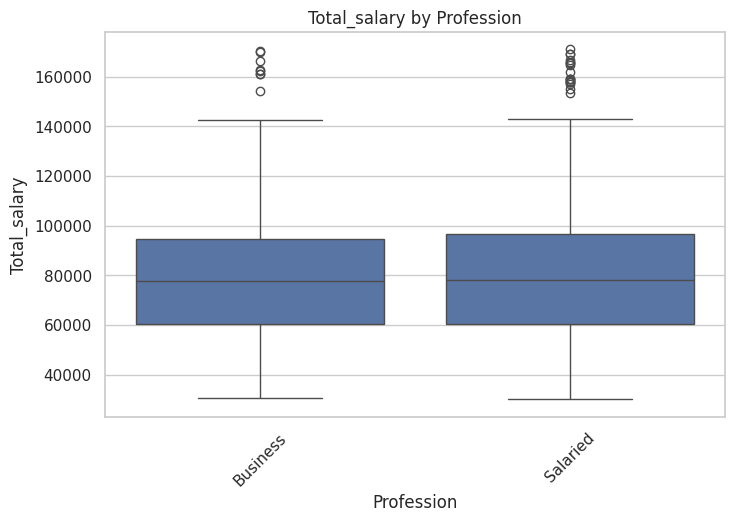


Group statistics for Total_salary by Profession:
            count          mean           std      min      25%      50%  \
Profession                                                                 
Business    685.0  78658.102190  24375.381464  30600.0  60400.0  77700.0   
Salaried    896.0  80365.959821  26395.282966  30000.0  60500.0  78000.0   

                75%       max  
Profession                     
Business    94800.0  170400.0  
Salaried    96650.0  171000.0  


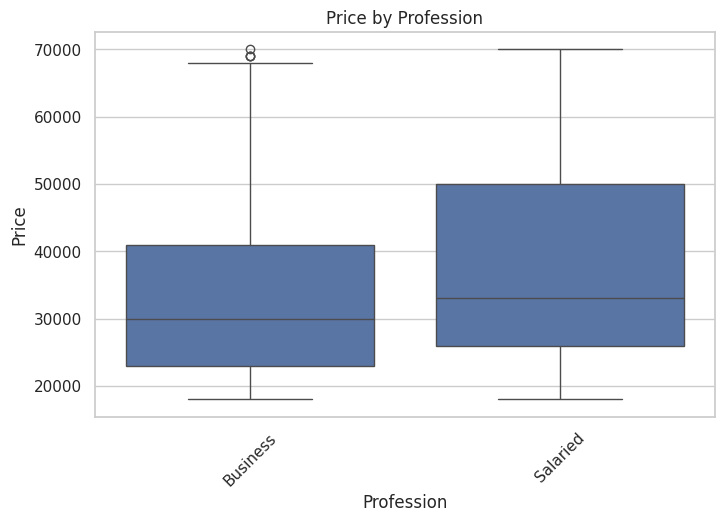


Group statistics for Price by Profession:
            count          mean           std      min      25%      50%  \
Profession                                                                 
Business    685.0  33353.284672  12911.331955  18000.0  23000.0  30000.0   
Salaried    896.0  37313.616071  13926.016563  18000.0  26000.0  33000.0   

                75%      max  
Profession                    
Business    41000.0  70000.0  
Salaried    50000.0  70000.0  


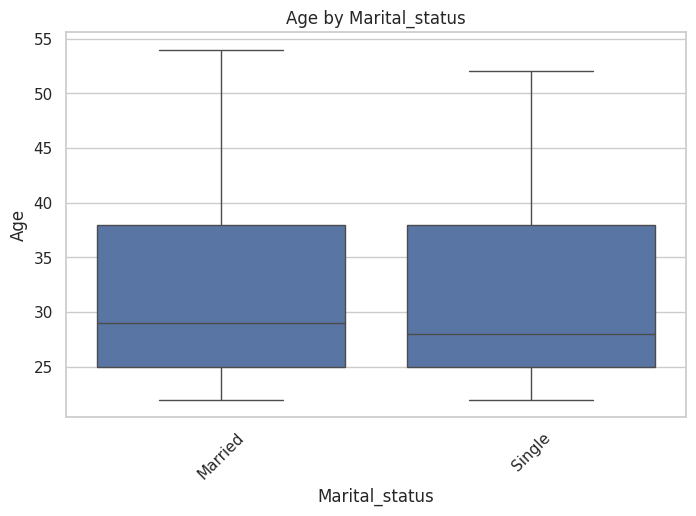


Group statistics for Age by Marital_status:
                 count       mean       std   min   25%   50%   75%   max
Marital_status                                                           
Married         1443.0  31.995842  8.433717  22.0  25.0  29.0  38.0  54.0
Single           138.0  31.152174  8.335924  22.0  25.0  28.0  38.0  52.0


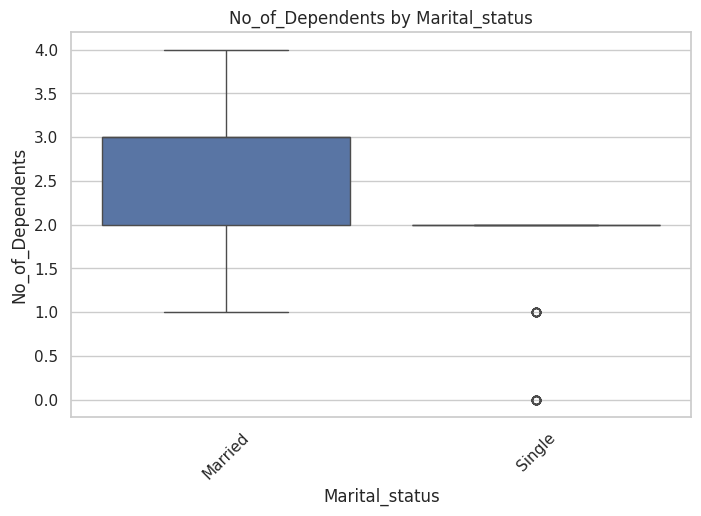


Group statistics for No_of_Dependents by Marital_status:
                 count      mean       std  min  25%  50%  75%  max
Marital_status                                                     
Married         1443.0  2.539155  0.921517  1.0  2.0  3.0  3.0  4.0
Single           138.0  1.608696  0.729311  0.0  2.0  2.0  2.0  2.0


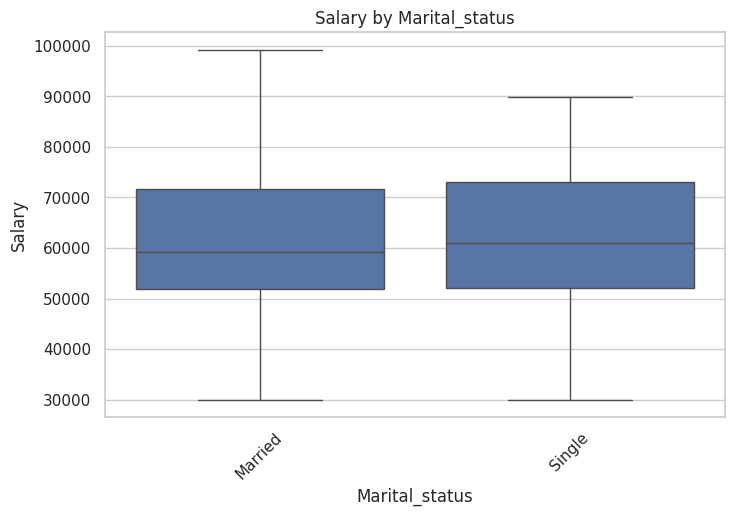


Group statistics for Salary by Marital_status:
                 count          mean           std      min      25%      50%  \
Marital_status                                                                  
Married         1443.0  60412.404712  14599.913266  30000.0  51900.0  59300.0   
Single           138.0  60181.159420  15490.512994  30000.0  52150.0  60900.0   

                    75%      max  
Marital_status                    
Married         71700.0  99300.0  
Single          72975.0  89900.0  


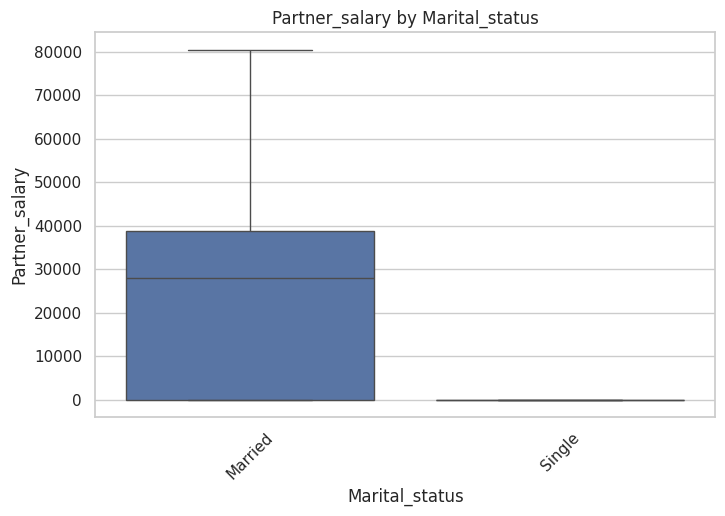


Group statistics for Partner_salary by Marital_status:
                 count          mean           std  min  25%      50%  \
Marital_status                                                          
Married         1353.0  22049.297857  19427.729866  0.0  0.0  28000.0   
Single           122.0      0.000000      0.000000  0.0  0.0      0.0   

                    75%      max  
Marital_status                    
Married         38700.0  80500.0  
Single              0.0      0.0  


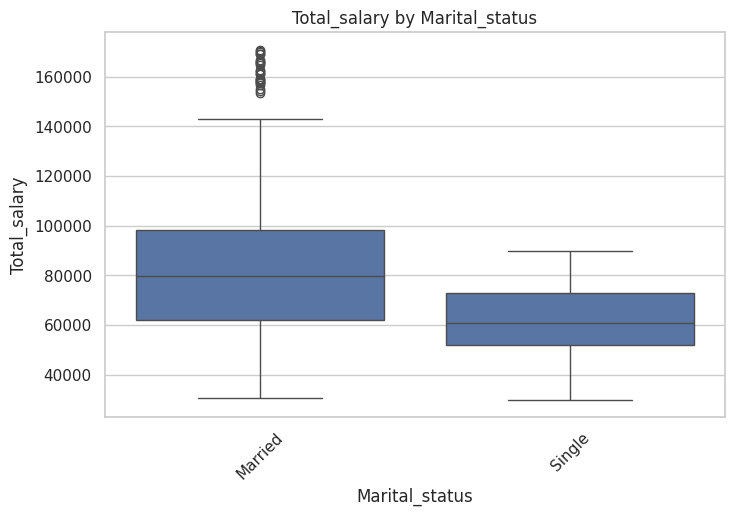


Group statistics for Total_salary by Marital_status:
                 count          mean           std      min      25%      50%  \
Marital_status                                                                  
Married         1443.0  81485.585586  25546.068638  30600.0  62200.0  79800.0   
Single           138.0  60181.159420  15490.512994  30000.0  52150.0  60900.0   

                    75%       max  
Marital_status                     
Married         98100.0  171000.0  
Single          72975.0   89900.0  


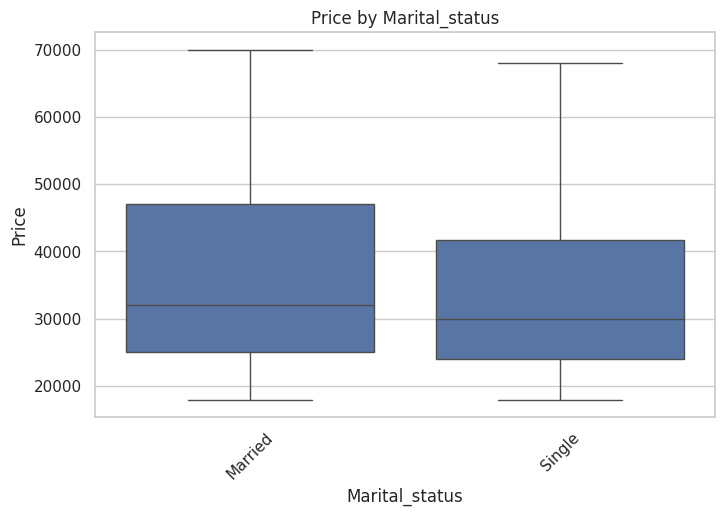


Group statistics for Price by Marital_status:
                 count         mean           std      min      25%      50%  \
Marital_status                                                                 
Married         1443.0  35800.41580  13723.202856  18000.0  25000.0  32000.0   
Single           138.0  33478.26087  12509.393487  18000.0  24000.0  30000.0   

                    75%      max  
Marital_status                    
Married         47000.0  70000.0  
Single          41750.0  68000.0  


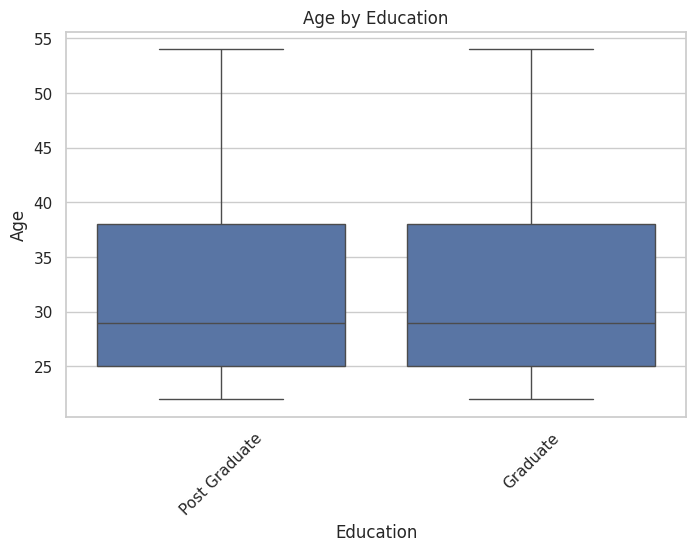


Group statistics for Age by Education:
               count       mean       std   min   25%   50%   75%   max
Education                                                              
Graduate       596.0  31.843960  8.251966  22.0  25.0  29.0  38.0  54.0
Post Graduate  985.0  31.969543  8.533357  22.0  25.0  29.0  38.0  54.0


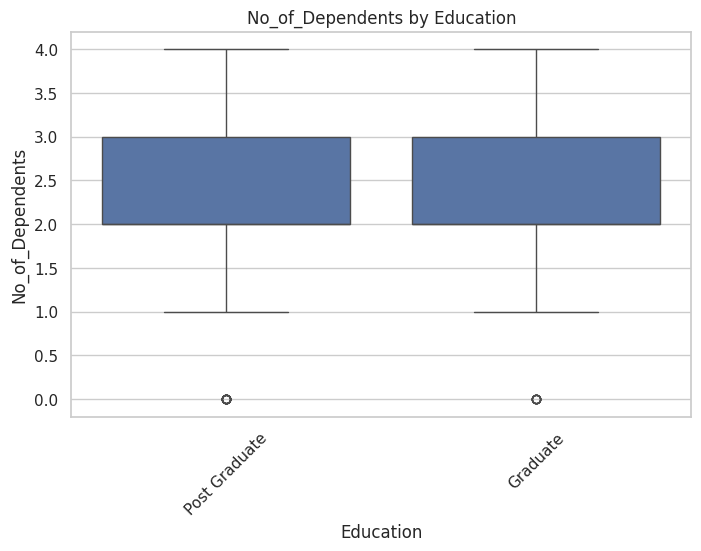


Group statistics for No_of_Dependents by Education:
               count      mean       std  min  25%  50%  75%  max
Education                                                        
Graduate       596.0  2.441275  0.949962  0.0  2.0  2.0  3.0  4.0
Post Graduate  985.0  2.468020  0.939881  0.0  2.0  2.0  3.0  4.0


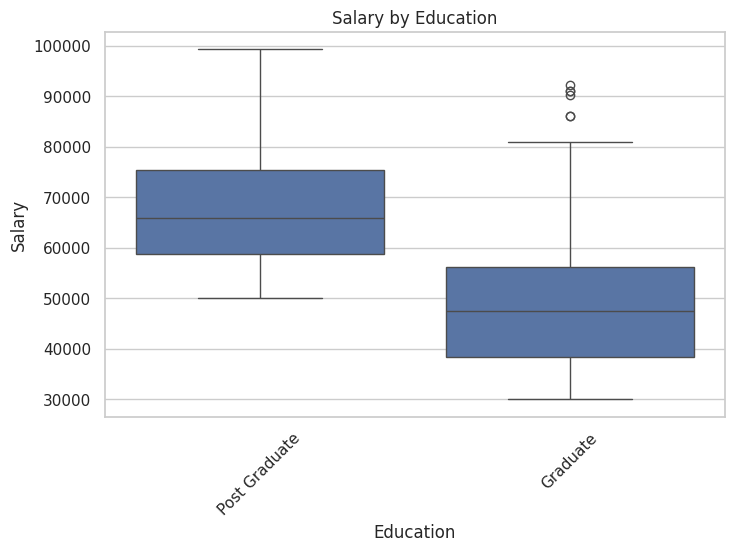


Group statistics for Salary by Education:
               count          mean           std      min      25%      50%  \
Education                                                                     
Graduate       596.0  48506.040268  12480.532623  30000.0  38375.0  47550.0   
Post Graduate  985.0  67584.263959  10688.737619  50000.0  58700.0  65800.0   

                   75%      max  
Education                        
Graduate       56100.0  92300.0  
Post Graduate  75300.0  99300.0  


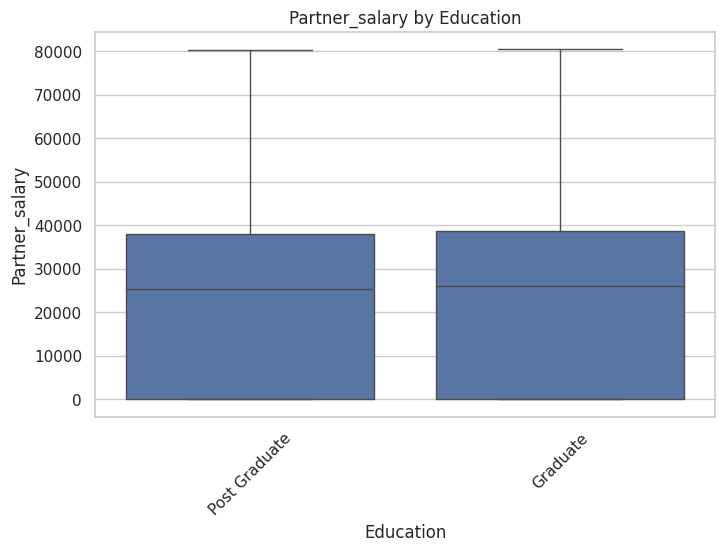


Group statistics for Partner_salary by Education:
               count          mean           std  min  25%      50%      75%  \
Education                                                                      
Graduate       551.0  21362.068966  19882.806517  0.0  0.0  26100.0  38700.0   
Post Graduate  924.0  19547.835498  19365.225719  0.0  0.0  25300.0  38100.0   

                   max  
Education               
Graduate       80500.0  
Post Graduate  80400.0  


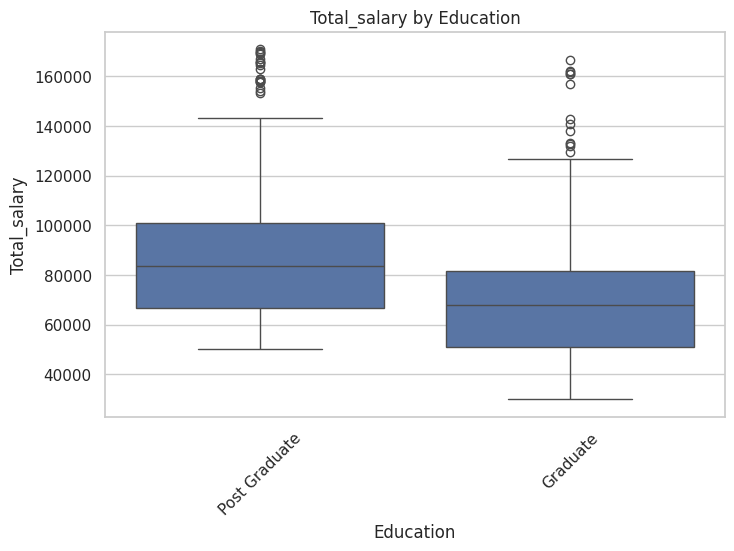


Group statistics for Total_salary by Education:
               count          mean          std      min      25%      50%  \
Education                                                                    
Graduate       596.0  68782.550336  25082.35774  30000.0  50975.0  67900.0   
Post Graduate  985.0  86187.106599  23518.80510  50100.0  66700.0  83700.0   

                    75%       max  
Education                          
Graduate        81725.0  166500.0  
Post Graduate  101100.0  171000.0  


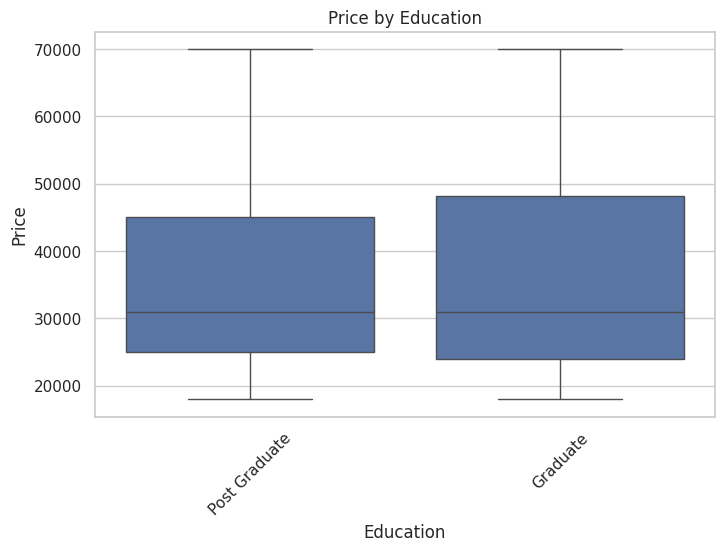


Group statistics for Price by Education:
               count          mean           std      min      25%      50%  \
Education                                                                     
Graduate       596.0  35907.718121  13997.594301  18000.0  24000.0  31000.0   
Post Graduate  985.0  35410.152284  13412.328181  18000.0  25000.0  31000.0   

                   75%      max  
Education                        
Graduate       48250.0  70000.0  
Post Graduate  45000.0  70000.0  


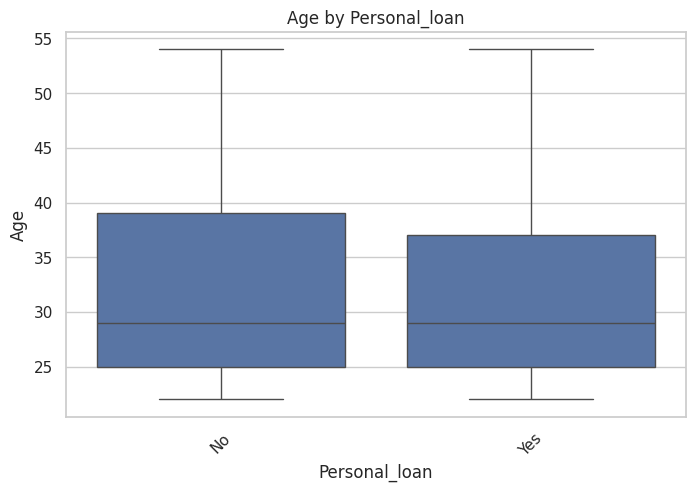


Group statistics for Age by Personal_loan:
               count       mean       std   min   25%   50%   75%   max
Personal_loan                                                          
No             789.0  32.518378  8.907376  22.0  25.0  29.0  39.0  54.0
Yes            792.0  31.328283  7.878233  22.0  25.0  29.0  37.0  54.0


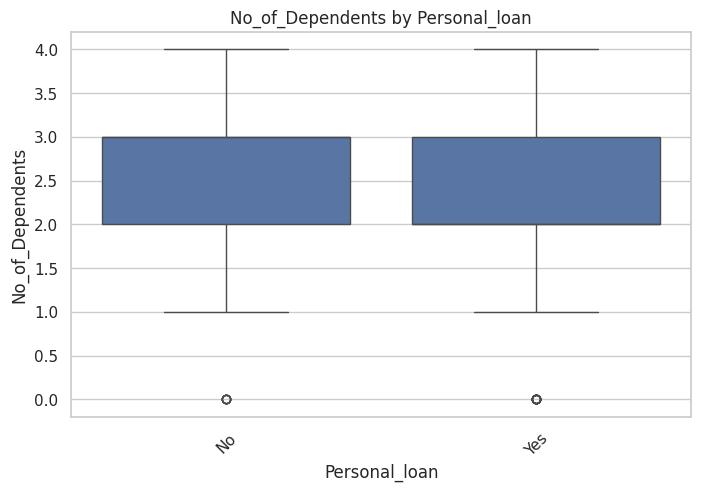


Group statistics for No_of_Dependents by Personal_loan:
               count      mean       std  min  25%  50%  75%  max
Personal_loan                                                    
No             789.0  2.552598  0.917309  0.0  2.0  3.0  3.0  4.0
Yes            792.0  2.363636  0.960189  0.0  2.0  2.0  3.0  4.0


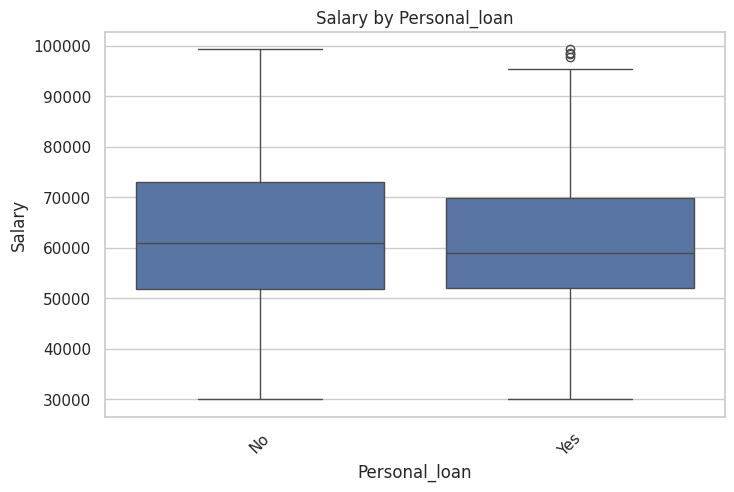


Group statistics for Salary by Personal_loan:
               count          mean           std      min      25%      50%  \
Personal_loan                                                                 
No             789.0  61248.288973  15269.018689  30000.0  51900.0  60900.0   
Yes            792.0  59539.393939  14015.653652  30100.0  51975.0  58900.0   

                   75%      max  
Personal_loan                    
No             73000.0  99300.0  
Yes            69950.0  99300.0  


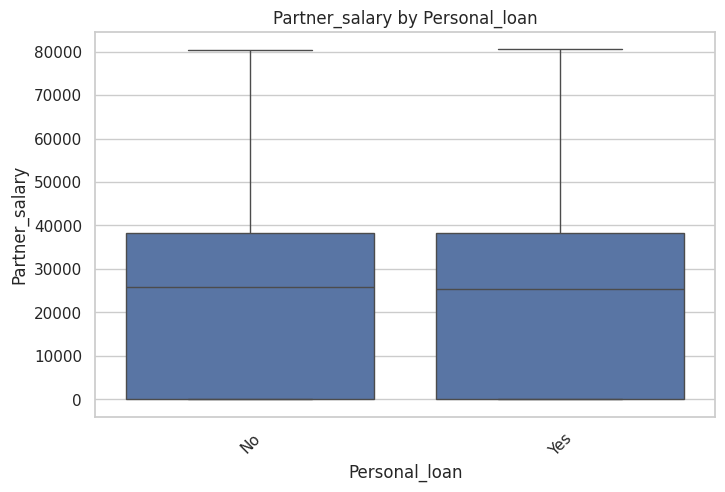


Group statistics for Partner_salary by Personal_loan:
               count          mean           std  min  25%      50%      75%  \
Personal_loan                                                                  
No             737.0  20842.876526  20343.588921  0.0  0.0  25800.0  38300.0   
Yes            738.0  19609.078591  18765.783738  0.0  0.0  25400.0  38300.0   

                   max  
Personal_loan           
No             80400.0  
Yes            80500.0  


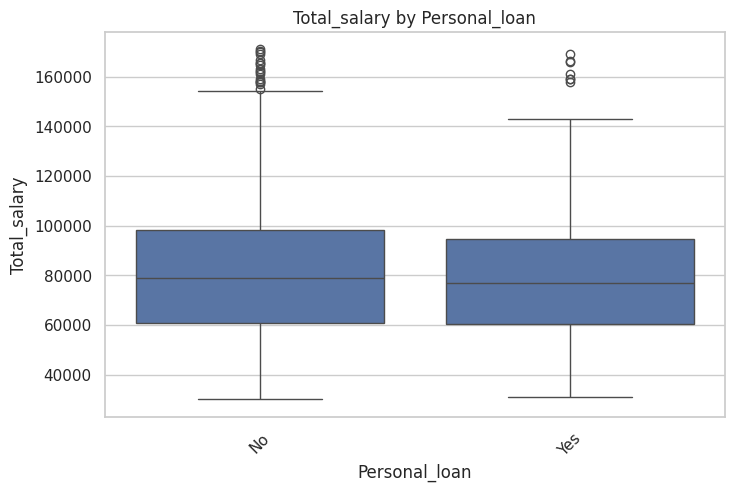


Group statistics for Total_salary by Personal_loan:
               count          mean           std      min      25%      50%  \
Personal_loan                                                                 
No             789.0  81077.566540  27132.119710  30000.0  60900.0  78800.0   
Yes            792.0  78179.924242  23790.254748  31100.0  60175.0  76850.0   

                   75%       max  
Personal_loan                     
No             98200.0  171000.0  
Yes            94625.0  169300.0  


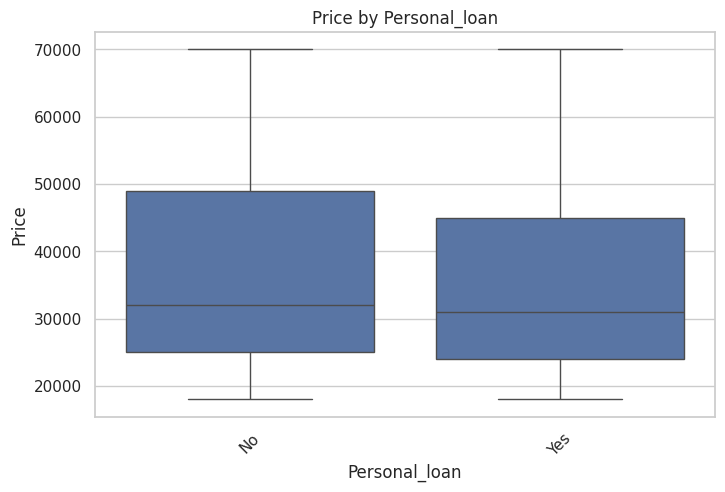


Group statistics for Price by Personal_loan:
               count          mean           std      min      25%      50%  \
Personal_loan                                                                 
No             789.0  36742.712294  14534.344526  18000.0  25000.0  32000.0   
Yes            792.0  34457.070707  12578.780338  18000.0  24000.0  31000.0   

                   75%      max  
Personal_loan                    
No             49000.0  70000.0  
Yes            45000.0  70000.0  


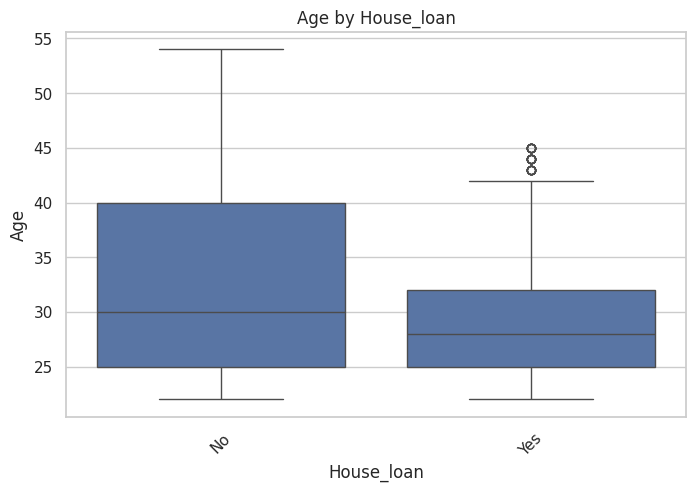


Group statistics for Age by House_loan:
             count       mean       std   min   25%   50%   75%   max
House_loan                                                           
No          1054.0  33.068311  9.219240  22.0  25.0  30.0  40.0  54.0
Yes          527.0  29.629981  5.934184  22.0  25.0  28.0  32.0  45.0


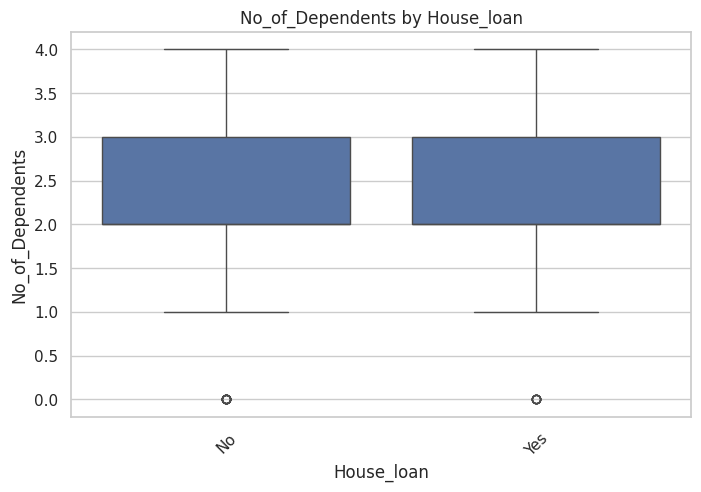


Group statistics for No_of_Dependents by House_loan:
             count      mean       std  min  25%  50%  75%  max
House_loan                                                     
No          1054.0  2.472486  0.937102  0.0  2.0  2.0  3.0  4.0
Yes          527.0  2.428843  0.956349  0.0  2.0  2.0  3.0  4.0


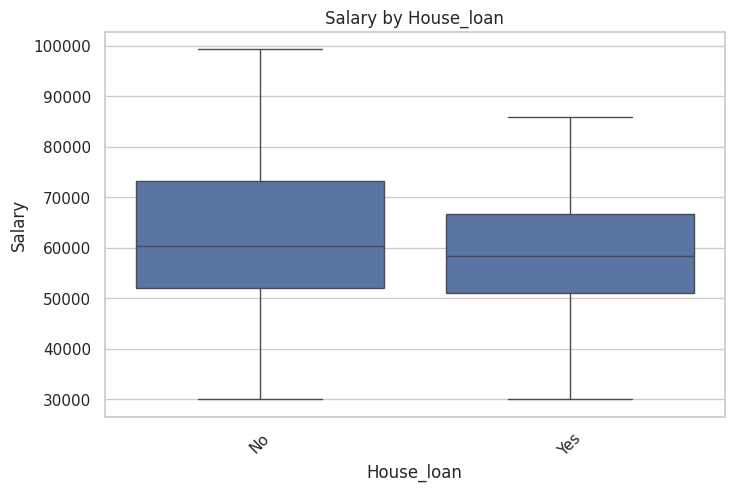


Group statistics for Salary by House_loan:
             count          mean           std      min      25%      50%  \
House_loan                                                                  
No          1054.0  61590.037951  15182.327952  30000.0  52100.0  60400.0   
Yes          527.0  57996.584440  13296.651416  30000.0  51150.0  58400.0   

                75%      max  
House_loan                    
No          73275.0  99300.0  
Yes         66650.0  85900.0  


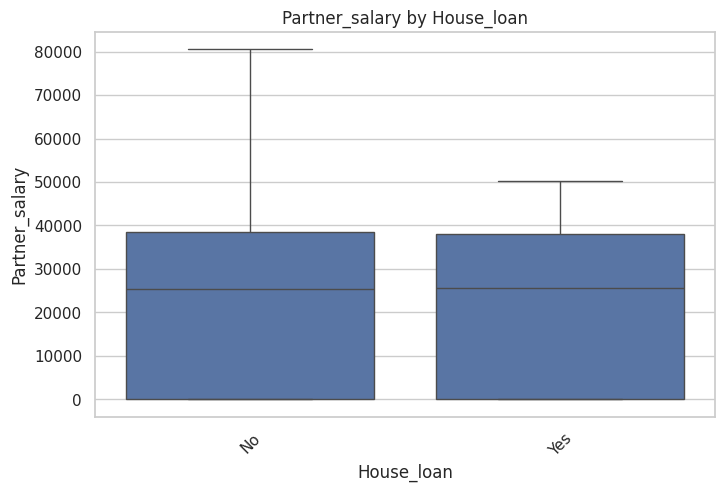


Group statistics for Partner_salary by House_loan:
            count          mean           std  min  25%      50%      75%  \
House_loan                                                                  
No          979.0  20678.243105  20548.880489  0.0  0.0  25500.0  38400.0   
Yes         496.0  19332.056452  17473.674300  0.0  0.0  25700.0  38100.0   

                max  
House_loan           
No          80500.0  
Yes         50300.0  


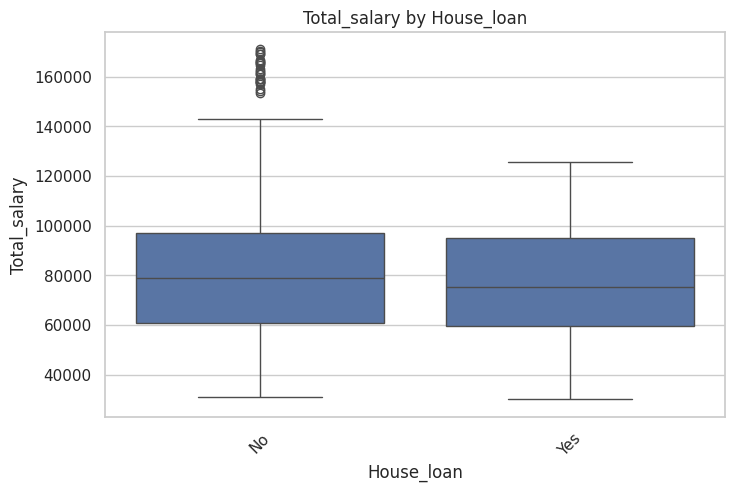


Group statistics for Total_salary by House_loan:
             count          mean           std      min      25%      50%  \
House_loan                                                                  
No          1054.0  81252.277040  26856.039296  31100.0  60900.0  79000.0   
Yes          527.0  76373.434535  22371.635868  30000.0  59550.0  75400.0   

                75%       max  
House_loan                     
No          97100.0  171000.0  
Yes         94850.0  125500.0  


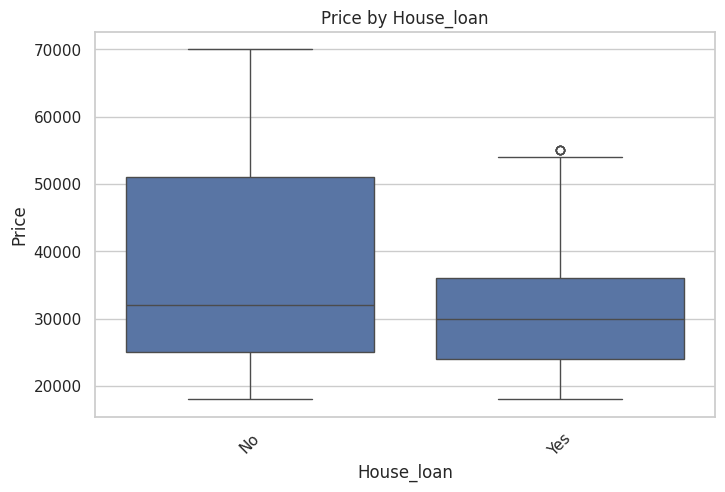


Group statistics for Price by House_loan:
             count          mean           std      min      25%      50%  \
House_loan                                                                  
No          1054.0  37707.779886  14816.702037  18000.0  25000.0  32000.0   
Yes          527.0  31377.609108   9596.008338  18000.0  24000.0  30000.0   

                75%      max  
House_loan                    
No          51000.0  70000.0  
Yes         36000.0  55000.0  


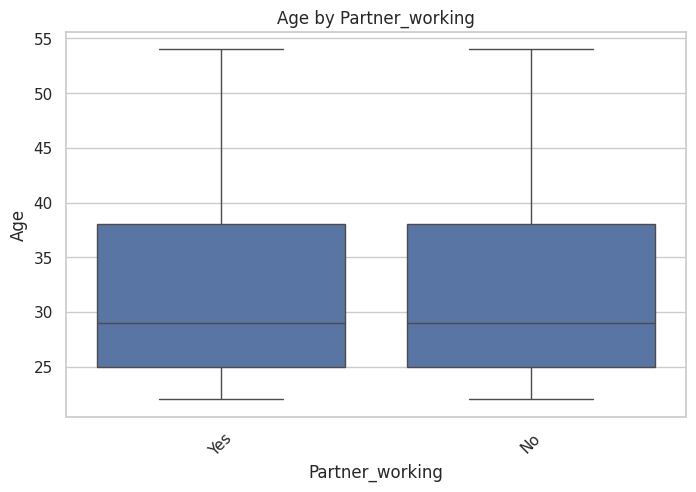


Group statistics for Age by Partner_working:
                 count      mean       std   min   25%   50%   75%   max
Partner_working                                                         
No               713.0  32.13885  8.518260  22.0  25.0  29.0  38.0  54.0
Yes              868.0  31.74424  8.350125  22.0  25.0  29.0  38.0  54.0


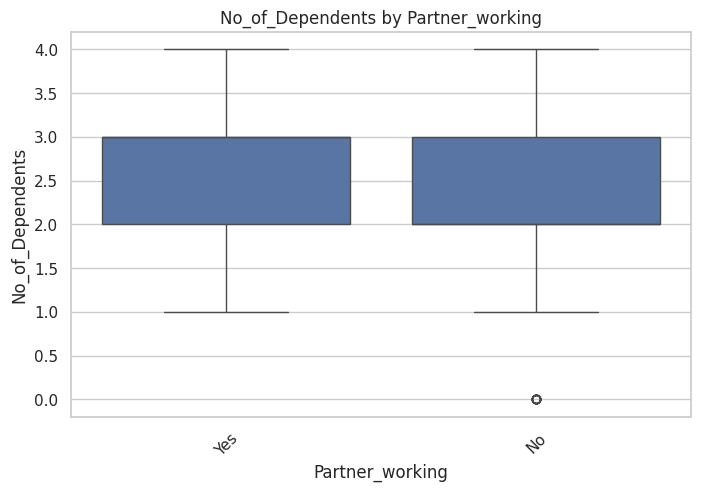


Group statistics for No_of_Dependents by Partner_working:
                 count      mean       std  min  25%  50%  75%  max
Partner_working                                                    
No               713.0  2.305750  0.988236  0.0  2.0  2.0  3.0  4.0
Yes              868.0  2.582949  0.886284  1.0  2.0  3.0  3.0  4.0


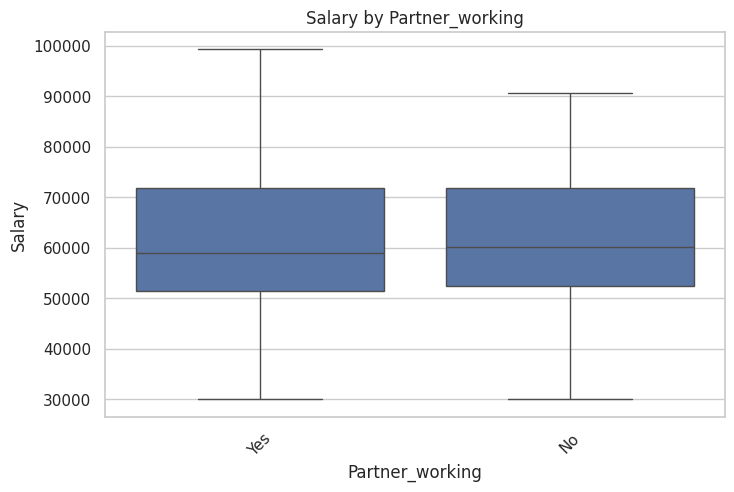


Group statistics for Salary by Partner_working:
                 count          mean           std      min      25%      50%  \
Partner_working                                                                 
No               713.0  60527.208976  14155.715691  30000.0  52400.0  60100.0   
Yes              868.0  60281.336406  15095.104030  30000.0  51375.0  59050.0   

                     75%      max  
Partner_working                    
No               71800.0  90700.0  
Yes              71925.0  99300.0  


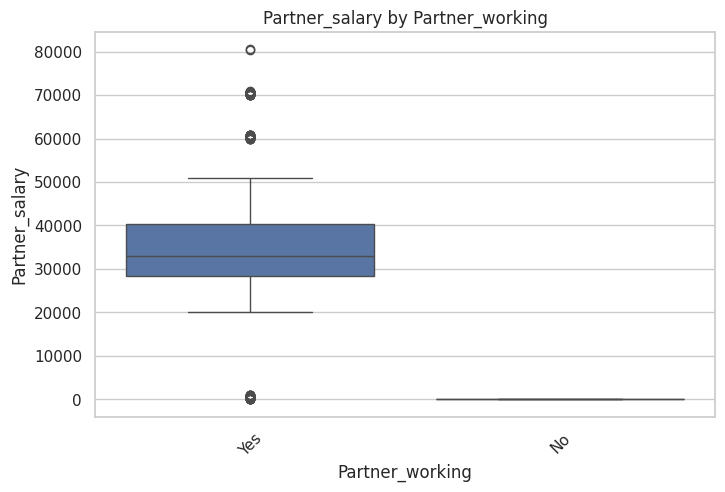


Group statistics for Partner_salary by Partner_working:
                 count          mean           std    min      25%      50%  \
Partner_working                                                               
No               623.0      0.000000      0.000000    0.0      0.0      0.0   
Yes              852.0  35014.906103  12046.487544  100.0  28400.0  32900.0   

                     75%      max  
Partner_working                    
No                   0.0      0.0  
Yes              40300.0  80500.0  


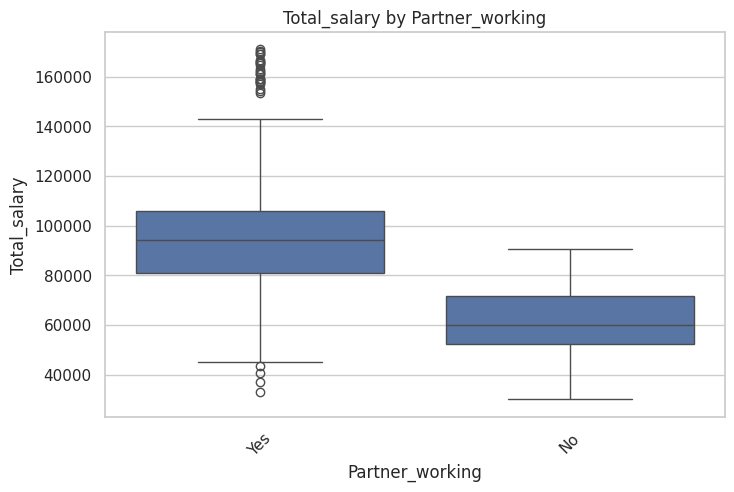


Group statistics for Total_salary by Partner_working:
                 count          mean           std      min      25%      50%  \
Partner_working                                                                 
No               713.0  60527.208976  14155.715691  30000.0  52400.0  60100.0   
Yes              868.0  95314.285714  21870.679019  32900.0  81000.0  94250.0   

                      75%       max  
Partner_working                      
No                71800.0   90700.0  
Yes              105900.0  171000.0  


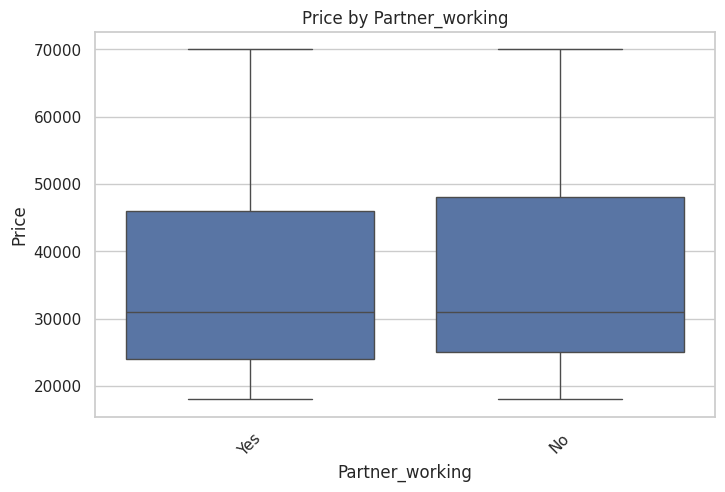


Group statistics for Price by Partner_working:
                 count          mean           std      min      25%      50%  \
Partner_working                                                                 
No               713.0  36000.000000  13817.734086  18000.0  25000.0  31000.0   
Yes              868.0  35267.281106  13479.532555  18000.0  24000.0  31000.0   

                     75%      max  
Partner_working                    
No               48000.0  70000.0  
Yes              46000.0  70000.0  


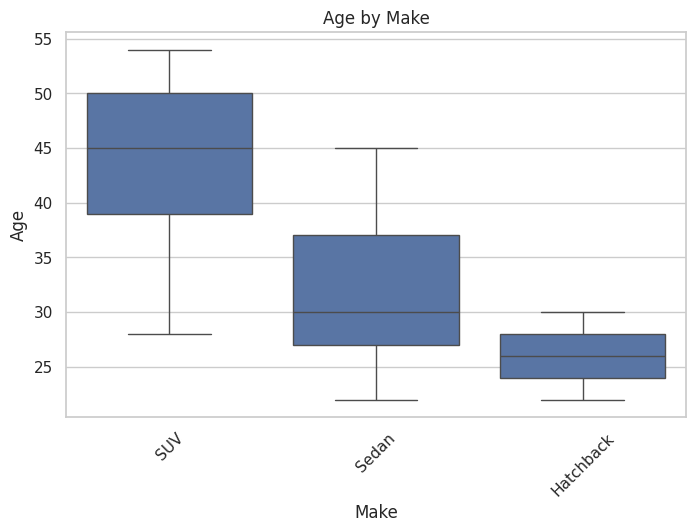


Group statistics for Age by Make:
           count       mean       std   min   25%   50%   75%   max
Make                                                               
Hatchback  582.0  25.726804  2.500796  22.0  24.0  26.0  28.0  30.0
SUV        297.0  43.989899  6.664491  28.0  39.0  45.0  50.0  54.0
Sedan      702.0  31.952991  6.520400  22.0  27.0  30.0  37.0  45.0


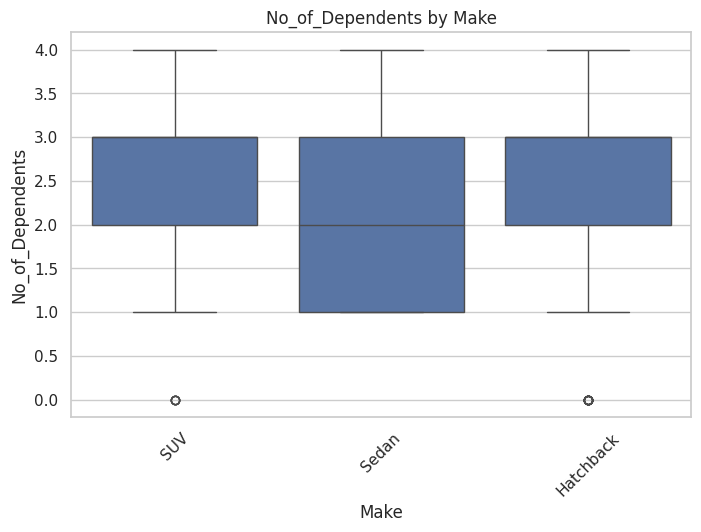


Group statistics for No_of_Dependents by Make:
           count      mean       std  min  25%  50%  75%  max
Make                                                         
Hatchback  582.0  2.778351  0.880470  0.0  2.0  3.0  3.0  4.0
SUV        297.0  2.609428  0.966838  0.0  2.0  3.0  3.0  4.0
Sedan      702.0  2.128205  0.874803  1.0  1.0  2.0  3.0  4.0


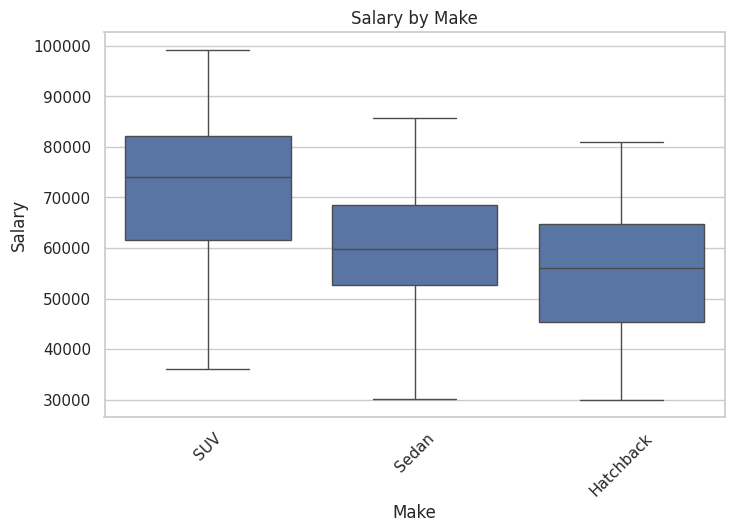


Group statistics for Salary by Make:
           count          mean           std      min      25%      50%  \
Make                                                                      
Hatchback  582.0  55083.505155  13084.408983  30000.0  45425.0  56100.0   
SUV        297.0  72266.666667  14252.816222  36000.0  61600.0  74000.0   
Sedan      702.0  59769.658120  13197.894815  30100.0  52700.0  59800.0   

               75%      max  
Make                         
Hatchback  64775.0  80900.0  
SUV        82200.0  99300.0  
Sedan      68600.0  85800.0  


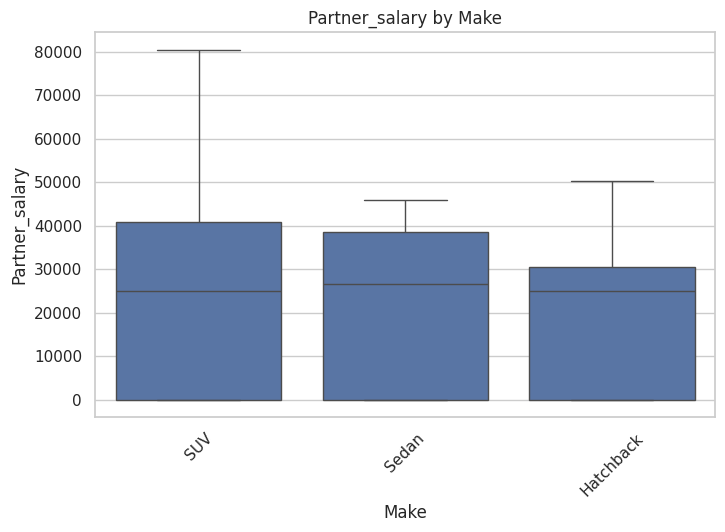


Group statistics for Partner_salary by Make:
           count          mean           std  min  25%      50%      75%  \
Make                                                                       
Hatchback  536.0  17100.373134  16512.965165  0.0  0.0  25000.0  30425.0   
SUV        281.0  24918.505338  26972.171093  0.0  0.0  24900.0  40900.0   
Sedan      658.0  20767.173252  17599.578440  0.0  0.0  26650.0  38500.0   

               max  
Make                
Hatchback  50300.0  
SUV        80500.0  
Sedan      45900.0  


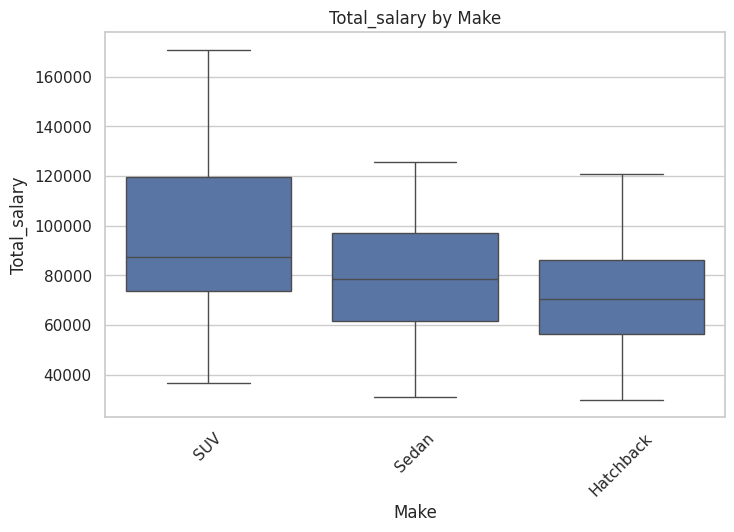


Group statistics for Total_salary by Make:
           count          mean           std      min      25%      50%  \
Make                                                                      
Hatchback  582.0  71018.041237  21017.605953  30000.0  56400.0  70450.0   
SUV        297.0  96591.582492  32140.509137  36800.0  73700.0  87600.0   
Sedan      702.0  79584.757835  22025.133708  31100.0  61650.0  78750.0   

                75%       max  
Make                           
Hatchback   86375.0  121000.0  
SUV        119600.0  171000.0  
Sedan       97175.0  125500.0  


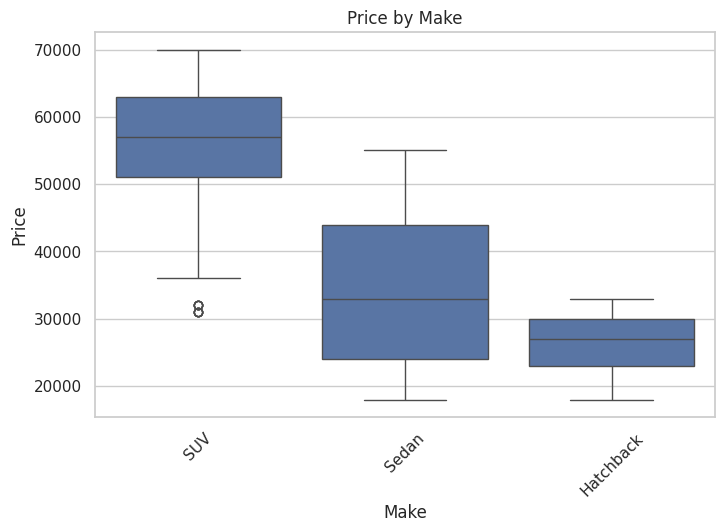


Group statistics for Price by Make:
           count          mean           std      min      25%      50%  \
Make                                                                      
Hatchback  582.0  26474.226804   4290.467640  18000.0  23000.0  27000.0   
SUV        297.0  55824.915825   9218.242714  31000.0  51000.0  57000.0   
Sedan      702.0  34603.988604  11152.164304  18000.0  24000.0  33000.0   

               75%      max  
Make                         
Hatchback  30000.0  33000.0  
SUV        63000.0  70000.0  
Sedan      44000.0  55000.0  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the data
df = pd.read_csv('austo_automobile .csv')

categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for cat in categorical_cols:
   for num in numerical_cols:
       plt.figure(figsize=(8, 5))
       sns.boxplot(x=df[cat], y=df[num])
       plt.title(f'{num} by {cat}')
       plt.xticks(rotation=45)
       plt.show()

       print(f"\nGroup statistics for {num} by {cat}:")
       print(df.groupby(cat)[num].describe())


## 1. Do men tend to prefer SUVs more compared to women?

In [ ]:
print(df[['Gender', 'Make']].head())

   Gender Make
0    Male  SUV
1   Femal  SUV
2  Female  SUV
3  Female  SUV
4    Male  SUV


In [ ]:
suv_counts = df[df['Make'] == 'SUV']['Gender'].value_counts()
print(suv_counts)

Gender
Female    171
Male      118
Femal       1
Femle       1
Name: count, dtype: int64


/tmp/ipython-input-750226663.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=suv_proportion.index, y=suv_proportion.values, palette="magma")


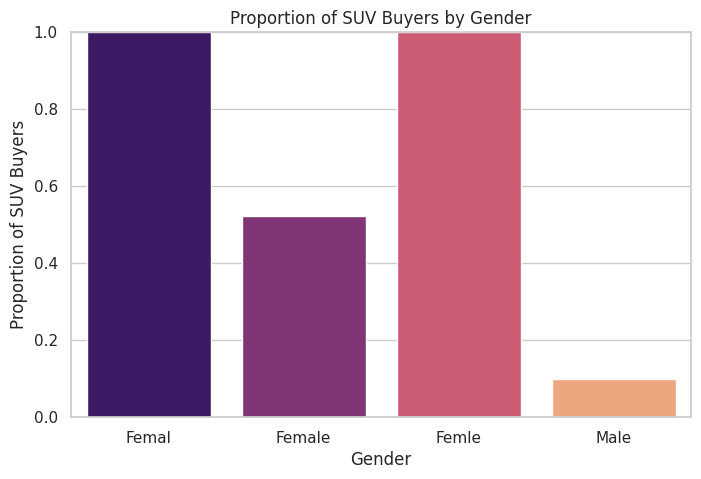

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=suv_proportion.index, y=suv_proportion.values, palette="magma")
plt.title("Proportion of SUV Buyers by Gender")
plt.xlabel("Gender")
plt.ylabel("Proportion of SUV Buyers")
plt.ylim(0, 1)
plt.show()

/tmp/ipython-input-1558748431.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=suv_counts.index, y=suv_counts.values, palette="viridis")


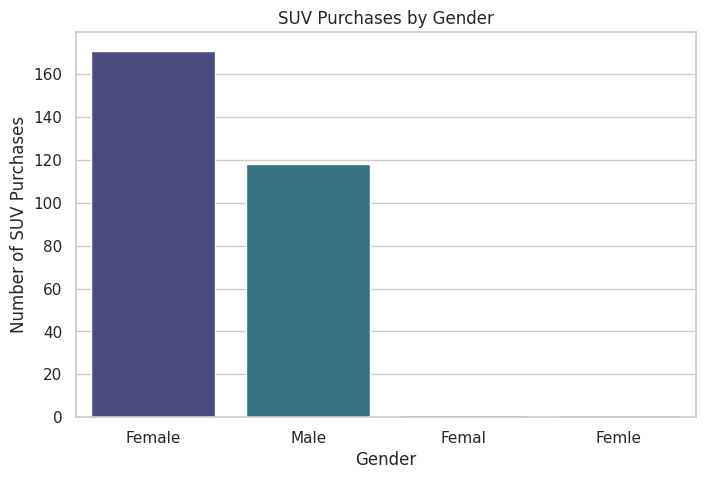

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x=suv_counts.index, y=suv_counts.values, palette="viridis")
plt.title("SUV Purchases by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of SUV Purchases")
plt.show()

In [ ]:
total_by_gender = df['Gender'].value_counts()
suv_proportion = suv_counts / total_by_gender
print(suv_proportion)

Gender
Femal     1.000000
Female    0.522936
Femle     1.000000
Male      0.098415
Name: count, dtype: float64


# 2. What is the likelihood of a salaried person buying a Sedan?

In [ ]:
import pandas as pd

salaried_df = df[df['Salary'] > 0]

In [ ]:

total_salaried = len(salaried_df)

salaried_sedan = salaried_df[salaried_df['Make'] == 'Sedan']
salaried_sedan_count = len(salaried_sedan)

likelihood = salaried_sedan_count / total_salaried
print(f"Likelihood of a salaried person buying a Sedan: {likelihood:.2%}")

Likelihood of a salaried person buying a Sedan: 44.40%


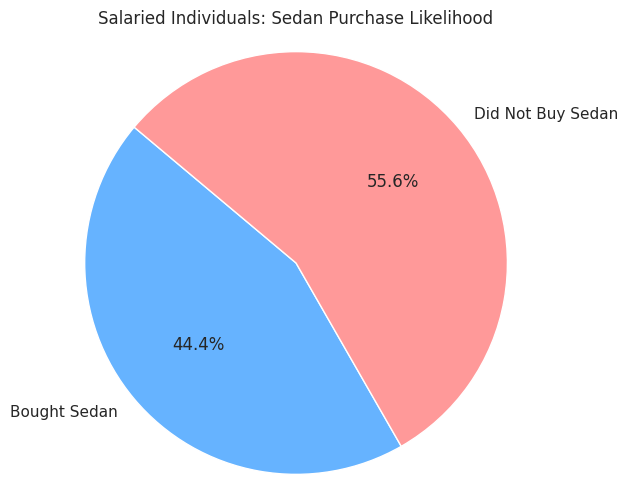

In [ ]:
import matplotlib.pyplot as plt

labels = ['Bought Sedan', 'Did Not Buy Sedan']
sizes = [salaried_sedan_count, total_salaried - salaried_sedan_count]
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Salaried Individuals: Sedan Purchase Likelihood")
plt.axis('equal')
plt.show()

In [ ]:
non_salaried_df = df[df['Salary'] == 0]
non_salaried_sedan = non_salaried_df[non_salaried_df['Make'] == 'Sedan']
salaried_likelihood = salaried_sedan_count / len(salaried_df)
if len(non_salaried_df) > 0:
    non_salaried_likelihood = len(non_salaried_sedan) / len(non_salaried_df)
    print(f"Non-Salaried Sedan Likelihood: {non_salaried_likelihood:.2%}")
else:
    print("There are no non-salaried individuals in the dataset.")
    print(f"Salaried Sedan Likelihood: {salaried_likelihood:.2%}")

There are no non-salaried individuals in the dataset.
Salaried Sedan Likelihood: 44.40%


## 3. What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
data = {
    'Purchased': [120, 80],  # SUV, Sedan
    'Not Purchased': [30, 50]  # SUV, Sedan
}
vehicle_df = pd.DataFrame(data, index=['SUV', 'Sedan'])
chi2, p, dof, expected = chi2_contingency(vehicle_df)
print("Observed Data:")
print(vehicle_df)
print("\nExpected Frequencies:")
print(pd.DataFrame(expected, index=['SUV', 'Sedan'], columns=['Purchased', 'Not Purchased']))
print(f"\nChi-square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("\nConclusion: The difference in SUV and Sedan purchases among salaried males is statistically significant.")
else:
    print("\nConclusion: The difference in SUV and Sedan purchases among salaried males is not statistically significant.")

Observed Data:
       Purchased  Not Purchased
SUV          120             30
Sedan         80             50

Expected Frequencies:
        Purchased  Not Purchased
SUV    107.142857      42.857143
Sedan   92.857143      37.142857

Chi-square Statistic: 10.7437
Degrees of Freedom: 1
P-value: 0.0010

Conclusion: The difference in SUV and Sedan purchases among salaried males is statistically significant.


# 4. How does the amount spent on purchasing automobiles vary by gender?


In [ ]:
import pandas as pd
print(df[['Gender', 'Price']].head())

   Gender  Price
0    Male  61000
1   Femal  61000
2  Female  57000
3  Female  61000
4    Male  57000


In [ ]:
summary = df.groupby('Gender')['Price'].describe()
print(summary)

         count          mean           std      min      25%      50%  \
Gender                                                                  
Femal      1.0  61000.000000           NaN  61000.0  61000.0  61000.0   
Female   327.0  47611.620795  11213.991567  20000.0  38000.0  49000.0   
Femle      1.0  65000.000000           NaN  65000.0  65000.0  65000.0   
Male    1199.0  32817.347790  12299.239195  18000.0  24000.0  29000.0   

            75%      max  
Gender                    
Femal   61000.0  61000.0  
Female  55000.0  69000.0  
Femle   65000.0  65000.0  
Male    37500.0  70000.0  


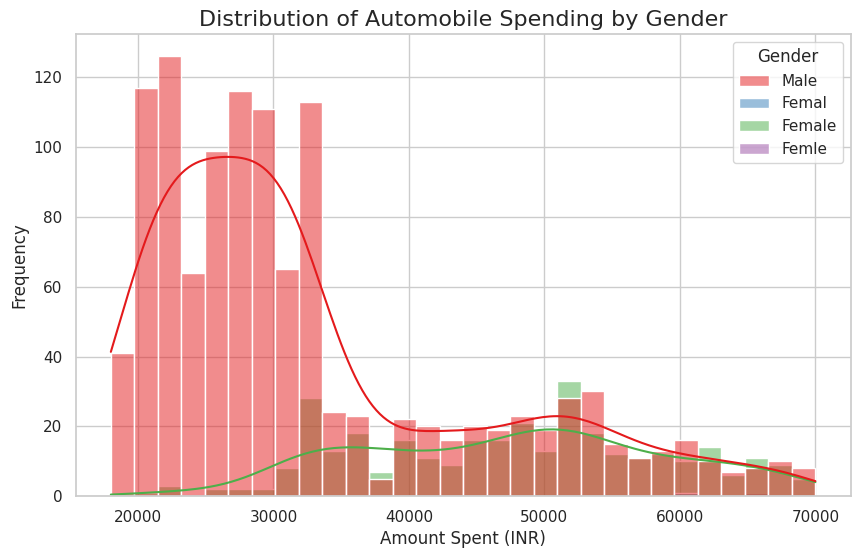

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Price', hue='Gender', kde=True, bins=30, palette='Set1')
plt.title('Distribution of Automobile Spending by Gender', fontsize=16)
plt.xlabel('Amount Spent (INR)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

/tmp/ipython-input-3129415689.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Price', data=df, palette='Set2')


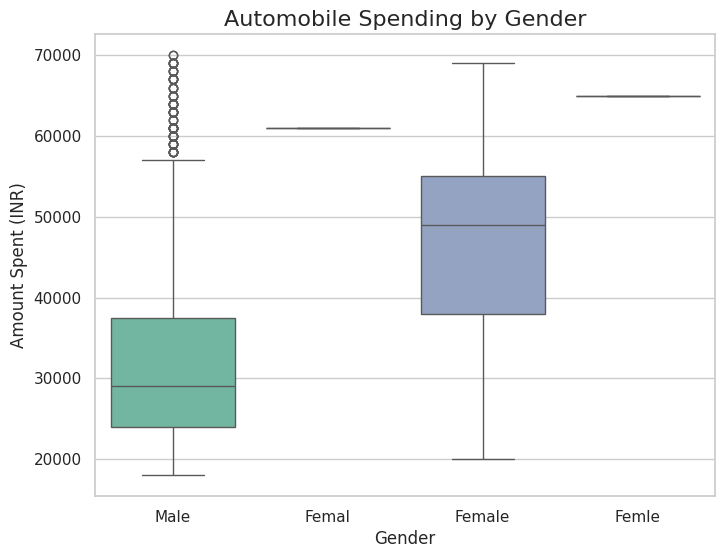

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Price', data=df, palette='Set2')
plt.title('Automobile Spending by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Amount Spent (INR)', fontsize=12)
plt.show()

# 5.How much money was spent on purchasing automobiles by individuals who took a personal loan?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print(df.head())
df['Personal_loan'] = df['Personal_loan'].astype(str)
loan_df = df[df['Personal_loan'].str.lower() == 'yes']
total_spent = loan_df['Price'].sum()
print(f"Total amount spent by individuals with personal loans: ₹{total_spent:,.0f}")

   Age  Gender Profession Marital_status      Education  No_of_Dependents  \
0   53    Male   Business        Married  Post Graduate                 4   
1   53   Femal   Salaried        Married  Post Graduate                 4   
2   53  Female   Salaried        Married  Post Graduate                 3   
3   53  Female   Salaried        Married       Graduate                 2   
4   53    Male   Salaried        Married  Post Graduate                 3   

  Personal_loan House_loan Partner_working  Salary  Partner_salary  \
0            No         No             Yes   99300         70700.0   
1           Yes         No             Yes   95500         70300.0   
2            No         No             Yes   97300         60700.0   
3           Yes         No             Yes   72500         70300.0   
4            No         No             Yes   79700         60200.0   

   Total_salary  Price Make  
0        170000  61000  SUV  
1        165800  61000  SUV  
2        158000  57000  SU

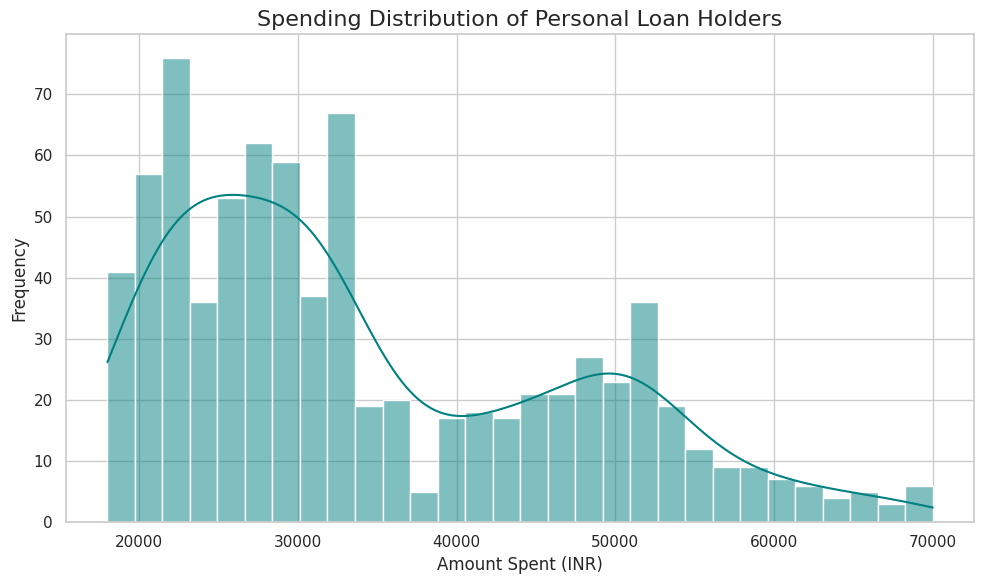

In [ ]:
sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))
sns.histplot(loan_df['Price'], bins=30, kde=True, color='teal')
plt.title('Spending Distribution of Personal Loan Holders', fontsize=16)
plt.xlabel('Amount Spent (INR)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipython-input-248739949.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Personal_loan', y='Price', data=df, palette='Set2')


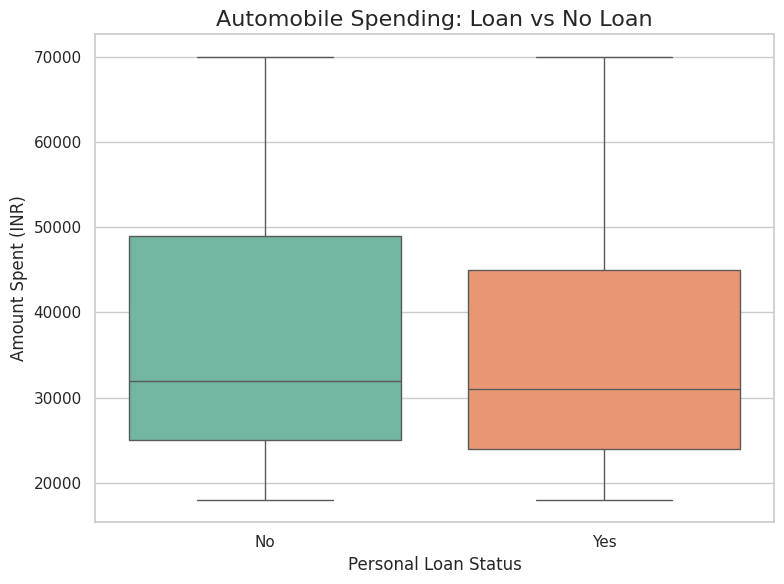

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Personal_loan', y='Price', data=df, palette='Set2')
plt.title('Automobile Spending: Loan vs No Loan', fontsize=16)
plt.xlabel('Personal Loan Status', fontsize=12)
plt.ylabel('Amount Spent (INR)', fontsize=12)
plt.tight_layout()
plt.show()

# 6. How does having a working partner influence the purchase of higher-priced cars?

/tmp/ipython-input-834051885.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Has_Working_Partner', y='High_Priced_Car', data=high_price_counts, palette='viridis')


Summary Statistics by Partner Status:
                      count       mean       std       min        25%  \
Has_Working_Partner                                                    
No                   256.0  14.942714  5.007863  1.745151  11.433281   
Yes                  244.0  18.251704  5.174261  2.135394  14.860782   

                           50%        75%        max  
Has_Working_Partner                                   
No                   15.107321  18.320081  27.866799  
Yes                  18.313827  21.567954  39.361676  

Proportion of High-Priced Car Purchases:
   Has_Working_Partner  High_Priced_Car
0                  No         0.156250
1                 Yes         0.381148


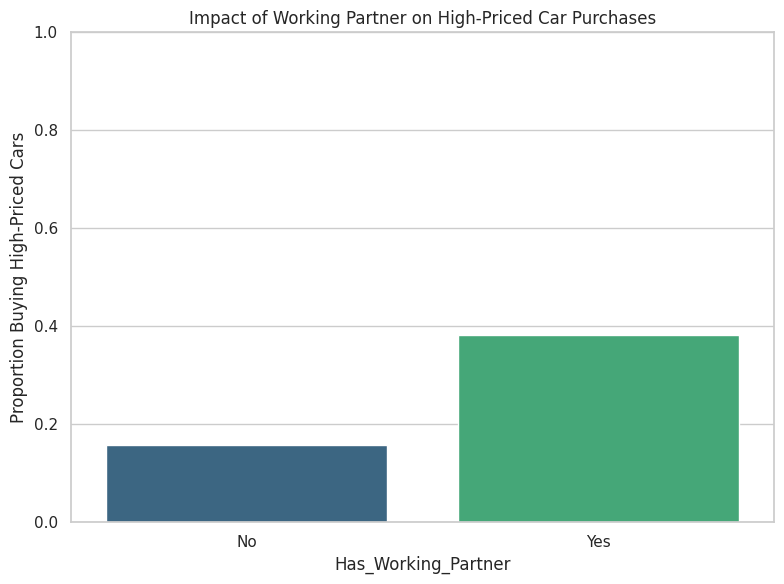

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set(style="whitegrid")

np.random.seed(42)
n = 500

data = pd.DataFrame({
    'Has_Working_Partner': np.random.choice(['Yes', 'No'], size=n),
    'Car_Price': np.random.normal(loc=15, scale=5, size=n)  # in lakhs
})
mask = data['Has_Working_Partner'] == 'Yes'
data.loc[mask, 'Car_Price'] += np.random.normal(loc=3, scale=2, size=mask.sum())

data['High_Priced_Car'] = data['Car_Price'] > 20

plt.figure(figsize=(8, 6))
high_price_counts = data.groupby('Has_Working_Partner')['High_Priced_Car'].mean().reset_index()
sns.barplot(x='Has_Working_Partner', y='High_Priced_Car', data=high_price_counts, palette='viridis')
plt.ylabel('Proportion Buying High-Priced Cars')
plt.title('Impact of Working Partner on High-Priced Car Purchases')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("high_priced_car_by_partner_status.png")

summary = data.groupby('Has_Working_Partner')['Car_Price'].describe()
print("Summary Statistics by Partner Status:\n", summary)

print("\nProportion of High-Priced Car Purchases:\n", high_price_counts)



/tmp/ipython-input-2050957610.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Has_Working_Partner', y='High_Priced_Car', data=high_price_counts, palette='viridis')


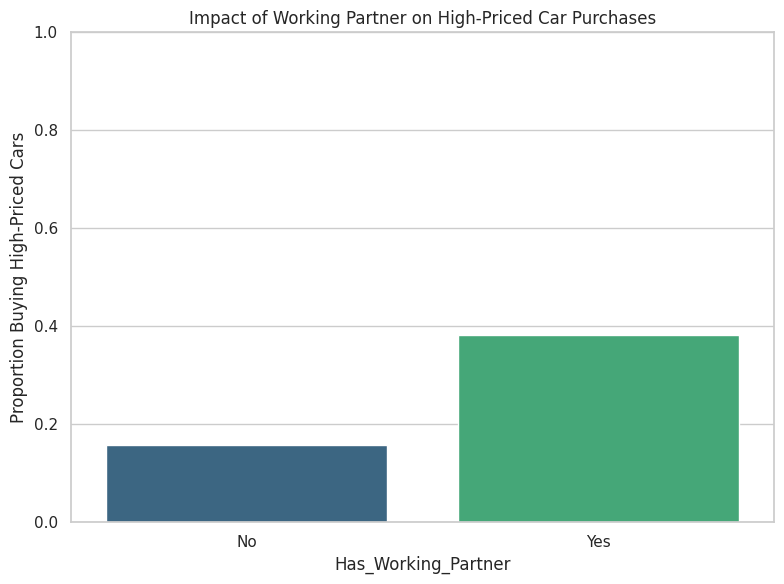

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
sns.set(style="whitegrid")

np.random.seed(42)
n = 500

data = pd.DataFrame({
    'Has_Working_Partner': np.random.choice(['Yes', 'No'], size=n),
    'Car_Price': np.random.normal(loc=15, scale=5, size=n)  # in lakhs
})
mask = data['Has_Working_Partner'] == 'Yes'
data.loc[mask, 'Car_Price'] += np.random.normal(loc=3, scale=2, size=mask.sum())
data['High_Priced_Car'] = data['Car_Price'] > 20
plt.figure(figsize=(8, 6))
high_price_counts = data.groupby('Has_Working_Partner')['High_Priced_Car'].mean().reset_index()
sns.barplot(x='Has_Working_Partner', y='High_Priced_Car', data=high_price_counts, palette='viridis')
plt.ylabel('Proportion Buying High-Priced Cars')
plt.title('Impact of Working Partner on High-Priced Car Purchases')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("high_priced_car_by_partner_status.png")



In [ ]:
summary = data.groupby('Has_Working_Partner')['Car_Price'].describe()
print("Summary Statistics by Partner Status:\n", summary)

print("\nProportion of High-Priced Car Purchases:\n", high_price_counts)

Summary Statistics by Partner Status:
                      count       mean       std       min        25%  \
Has_Working_Partner                                                    
No                   256.0  14.942714  5.007863  1.745151  11.433281   
Yes                  244.0  18.251704  5.174261  2.135394  14.860782   

                           50%        75%        max  
Has_Working_Partner                                   
No                   15.107321  18.320081  27.866799  
Yes                  18.313827  21.567954  39.361676  

Proportion of High-Priced Car Purchases:
   Has_Working_Partner  High_Priced_Car
0                  No         0.156250
1                 Yes         0.381148
